# Исследовательский анализ The Startup Market(Рынка Стартапов) для финансовой компании.

- Автор: Сереженко Елена

## Ведение

### Цели и задачи проекта

Подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.

**Задачи:**
1. Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
2. Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
3. Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
4. Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
5. Сравнить популярность и объёмы разных типов финансирования.
6. Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
7. Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
8. Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.


### Описание данных

Таблица `cb_investments` содержит информацию о компаниях и состоявшемся финансировании:
* `name` — название компании;
* `homepage_url` — ссылка на сайт компании;
* `category_list` — категории, в которых работает компания. Указываются через |;
* `market` — основной рынок или отрасль компании;
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США;
* `status` — текущий статус компании, например, operating, closed и так далее;
* `country_code` — код страны, например USA;
* `state_code` — код штата или региона, например CA;
* `region` — регион, например SF Bay Area;
* `city` — город, в котором расположена компания;
* `funding_rounds` — общее число раундов финансирования;
* `participants` — число участников в раундах финансирования;
* `founded_at` — дата основания компании;
* `founded_month` — месяц основания в формате YYYY-MM;
* `founded_quarter` — квартал основания в формате YYYY-QN;
* `founded_year` — год основания;
* `first_funding_at` — дата первого финансирования;
* `mid_funding_at` — дата среднего по времени раунда финансирования;
* `last_funding_at` — дата последнего финансирования;
* `seed` — сумма инвестиций на посевной стадии;
* `venture` — сумма венчурных инвестиций;
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг;
* `undisclosed` — сумма финансирования нераскрытого типа;
* `convertible_note` — сумма инвестиций через конвертируемые займы;
* `debt_financing` — сумма долгового финансирования;
* `angel` — сумма инвестиций от бизнес-ангелов;
* `grant` — сумма полученных грантов;
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений;
* `post_ipo_equity` — сумма финансирования после IPO;
* `post_ipo_debt` — сумма долгового финансирования после IPO;
* `secondary_market` — сумма сделок на вторичном рынке;
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг;
* `round_A — round_H` — сумма инвестиций в соответствующем раунде.


Таблица `cb_returns` содержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов:
* `year` — год возврата средств;
* `seed` — сумма возвратов от посевных инвестиций;
* `venture` — сумма возвратов от венчурных инвестиций;
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу;
* `undisclosed` — сумма возвратов нераскрытого типа;
* `convertible_note` — сумма возвратов через конвертируемые займы;
* `debt_financing` — сумма возвратов от долгового финансирования;
* `angel` — сумма возвратов бизнес-ангелам;
* `grant` — сумма возвратов по грантам;
* `private_equity` — сумма возвратов прямых (частных) вложений;
* `post_ipo_equity` — сумма возвратов от IPO;
* `post_ipo_debt` — сумма возвратов от долгового IPO;
* `secondary_market` — сумма возвратов от сделок на вторичном рынке;
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### Содержимое проекта

* [1. Загрузка данных и знакомство с ними.](#1.-Загрузка-данных-и-знакомство-с-ними)
    * [1.1. Вывод общей информации.](#1.1.-Вывод-общей-информации)
    * [1.2. Предобработка данных.](#1.2.-Предобработка-данных)
* [2. Инжиниринг признаков.](#2.-Инжиниринг-признаков)
    * [2.1. Группы по срокам финансирования.](#2.1.-Группы-по-срокам-финансирования)
    * [2.2 Выделение средних и нишевых сегментов рынка.](#2.2-Выделение-средних-и-нишевых-сегментов-рынка)
* [3. Работа с выбросами и анализ.](#3.-Работа-с-выбросами-и-анализ)
    * [3.1. Анализируем и помечаем выбросы в каждом из сегментов.](#3.1.-Анализируем-и-помечаем-выбросы-в-каждом-из-сегментов)
    * [3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии.](#3.2-Определяем-границы-рассматриваемого-периода,-отбрасываем-аномалии)
    * [3.3. Анализ типов финансирования по объёму и популярности.](#3.3.-Анализ-типов-финансирования-по-объёму-и-популярности)
* [4. Анализ динамики.](#4.-Анализ-динамики)
    * [4.1 Динамика предоставления финансирования по годам.](#4.1-Динамика-предоставления-финансирования-по-годам)
    * [4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов.](#4.2-Динамика-размера-общего-финансирования-по-массовым-сегментам-рынка-для-растущих-в-2014-году-сегментов)
    * [4.3 Годовая динамика доли возвращённых средств по типам финансирования.](#4.3-Годовая-динамика-доли-возвращённых-средств-по-типам-финансирования)
* [5. Итоговый вывод и рекомендации.](#5.-Итоговый-вывод-и-рекомендации)




## Шаг 1. Знакомство с данными: загрузка и предобработка

### 1.1. Вывод общей информации

Загрузка необходимых для работы библиотек.

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import missingno as msno
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

Выгрузка необходимых датасетов.

In [2]:
# Загружаем датасеты
df_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv", index_col='year')

Предпросмотр данных датасета `cb_investments`.

In [3]:
# Выводим первые строки датасета на экран
df_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Выводим информацию о датасета
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Датасет `df_investments` содержит 40 колонок и 54 294 строк.

После первичного анализа можно сделать следующие выводы:
* `name`, `homepage_url`, `category_list`, `city, region` - строковые типы данных, к ним корректно применен тип `object`;
* `founded_at`, `founded_month`, `founded_quarter`, `first_funding_at`, `mid_funding_at`, `last_funding_at` - тип данных `object`, но столбцы содержат даты, необходимо преобразовать в `datetime`;
* `founded_year` - тип данных `float64`, но столбец содержит год, необходимо преобразовать в `datetime`;
* `participants`, `funding_rounds` - тип данных `float64`, необходимо преобразовать в `integer`, уменьшить разрядность;
* `funding_total_usd` - тип данных `float64`, но столбец имеет числовые значения, необходимо скорретировать данные,  преобразовать в `float`, уменьшить разрядность;
* `market`, `status`, `country_code`, `state_code` - тип данных `object`, но столбцы содержат категориальные данные, необходимо преобразовать в `category`;
* `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market`, `product_crowdfunding`, `round_A`, `round_B`, `round_C`, `round_D`, `round_E`, `round_F`, `round_G`, `round_H` - тип данных `float64`, необходимо уменьшить разрядность.

Предпросмотр данных датасета `cb_returns`.

In [5]:
# Выводим первые строки датасета на экран
df_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
# Выводим информацию о датасета
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


Датасет `df_returns` содержит 14 колонок и 15 строк.

После первичного анализа можно сделать следующие выводы:
* столбцы содержат корректные типы данных;
* можно уменьшить их разрядность для оптимизации ресурсов.

### Промежуточный вывод

Знакоство с данными показало:

- не все названия столбцов указаны верно, нуждаются в изменениях;
- данные в столбцах соответсвуют названиям столбцов;
- требуется произвести преобразования типов данных(понижение разрядности);
- датасеты содержат пропуски.

### 1.2. Предобработка данных

#### Проверка названия столбцов и приведение к единому стилю

In [7]:
# Проверим названия столбцов в df_investments
df_investments.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

В названиях наблюдаются пропуски, необходимо их удалить. Приведём написание столбцов к нижнему регистру.

In [8]:
# Преобразование названий столбцов в df_investments
column_names = df_investments.columns.to_list()
for column_name in column_names:
    new_column_name = column_name.strip().lower()
    df_investments = df_investments.rename(columns={column_name: new_column_name})

In [9]:
# Контрольная проверка
df_investments.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

In [10]:
# Проверим названия колонок для df_returns
df_returns.columns

Index(['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

В данном датасете всё в норме.

#### Преобразование типов данных в датасетах

Поработаем со столбцом `funding_total_usd`.

In [11]:
df_investments['funding_total_usd'] = pd.to_numeric(
    df_investments['funding_total_usd'].str.replace(',', '', regex=False),
    errors='coerce')
df_investments['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

Поработаем с датами.

In [12]:
date_columns = [
    'founded_at',
    'first_funding_at',
    'mid_funding_at',
    'last_funding_at'
]

existing_cols = [col for col in date_columns if col in df_investments.columns]

# Применяем to_datetime с явным форматом
df_investments[existing_cols] = df_investments[existing_cols].apply(
    lambda col: pd.to_datetime(col, format='%Y-%m-%d', errors='coerce')
)

df_investments['founded_year'] = df_investments['founded_year'].astype('Int64')
df_investments['founded_month'] = pd.PeriodIndex(df_investments['founded_month'], freq='M')

In [13]:
# Проведём преобразование со столбцом founded_quarter на основе столбца founded_at через векторную операцию
df_investments['founded_quarter'] = (df_investments['founded_at'].dt.year.astype(str) +'-Q' +df_investments['founded_at'].dt.quarter.astype(str))

In [14]:
df_investments[['founded_at','first_funding_at','mid_funding_at','last_funding_at','founded_year','founded_quarter','founded_month']].head()

,founded_at,first_funding_at,mid_funding_at,last_funding_at,founded_year,founded_quarter,founded_month
0,NaT,2014-01-06,NaT,2014-01-06,1636,nan-Qnan,NaT
1,1785-01-01,2014-05-15,NaT,2014-05-15,1785,1785.0-Q1.0,NaT
2,1802-07-19,2009-07-02,2009-07-02,2009-07-02,1802,1802.0-Q3.0,NaT
3,1817-01-01,2013-11-21,2013-11-21,2014-11-03,1817,1817.0-Q1.0,NaT
4,1826-01-01,2014-01-14,NaT,2014-01-14,1826,1826.0-Q1.0,NaT


Уменьшим разрядность.

In [15]:
# Уменьшим разрядность в числовых столбцах при помощи созданной ниже функции
df_numb = [df_investments, df_returns]

for numb in df_numb:
    numb_columns = numb.columns.to_list()
    for numb_column in numb_columns:
        column_type = numb[numb_column].dtype
        if 'float' in str(column_type):
            numb[numb_column] = pd.to_numeric(numb[numb_column], errors='coerce', downcast='float')
        elif 'int' in str(column_type):
            numb[numb_column] = pd.to_numeric(numb[numb_column], errors='coerce', downcast='integer')

Приведём все текстовые значения в столбцах к единому стилю написания и проведём преобразование столбцов `market`, `status`, `country_code`, `state_code` в тип данных `category`.

In [16]:
# Приведём все текстовые значения в столбцах к единому стилю написания, убирём лишние пробелы

text_columns = ['name', 'homepage_url', 'category_list', 'region', 'city', 'market', 'status', 'country_code', 'state_code']

for text_column in text_columns:
    df_investments[text_column] = df_investments[text_column].str.lower().str.strip()

In [17]:
# Преобразуем в category при помощи созданной ниже функции
category_columns = ['market', 'status', 'country_code', 'state_code']

for category_column in category_columns:
    df_investments[category_column] = df_investments[category_column].astype('category')

Проверим датасеты после преобразовний.

In [18]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  category      
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  category      
 6   country_code          44165 non-null  category      
 7   state_code            30161 non-null  category      
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float32       
 11  participants          30473 non-null  float32       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

In [19]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float32
 1   venture               15 non-null     float32
 2   equity_crowdfunding   15 non-null     float32
 3   undisclosed           15 non-null     float32
 4   convertible_note      15 non-null     float32
 5   debt_financing        15 non-null     float32
 6   angel                 15 non-null     float32
 7   grant                 15 non-null     float32
 8   private_equity        15 non-null     float32
 9   post_ipo_equity       15 non-null     float32
 10  post_ipo_debt         15 non-null     float32
 11  secondary_market      15 non-null     float32
 12  product_crowdfunding  15 non-null     float32
dtypes: float32(13)
memory usage: 900.0 bytes


Произведены необходимые преобразования для столбцов, а именно уменьшены разрядность числовых значений, приведены корректные типы данных, регистры названий приведены к единому виду, столбец `year` назначен индексом.

#### Работа с пропусками в датасетах

Рассмотрим датасет `df_investments`.

In [20]:
# Применяем метод isna() к датаcету df_investments
df_investments.isna().sum().sort_values()

founded_quarter             0
seed                     4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_a                  4856
round_b                  4856
round_c                  4856
round_d                  4856
round_e                  4856
round_f                  4856
equity_crowdfunding      4856
venture                  4856
round_h                  4856
round_g                  4856
funding_rounds           4856
name                     4857
last_funding_at          4862
first_funding_at         4866
status                   6170
homepage_url             8305
market                   8817
category_list            8817
country_code            10129
region                  10129
city                    10972
funding_to

In [21]:
# Посчитаем долю строк с пропусками
df_investments.isna().mean().sort_values()

founded_quarter         0.000000
seed                    0.089439
undisclosed             0.089439
convertible_note        0.089439
debt_financing          0.089439
angel                   0.089439
grant                   0.089439
private_equity          0.089439
post_ipo_equity         0.089439
post_ipo_debt           0.089439
secondary_market        0.089439
product_crowdfunding    0.089439
round_a                 0.089439
round_b                 0.089439
round_c                 0.089439
round_d                 0.089439
round_e                 0.089439
round_f                 0.089439
equity_crowdfunding     0.089439
venture                 0.089439
round_h                 0.089439
round_g                 0.089439
funding_rounds          0.089439
name                    0.089457
last_funding_at         0.089549
first_funding_at        0.089623
status                  0.113641
homepage_url            0.152963
market                  0.162394
category_list           0.162394
country_co

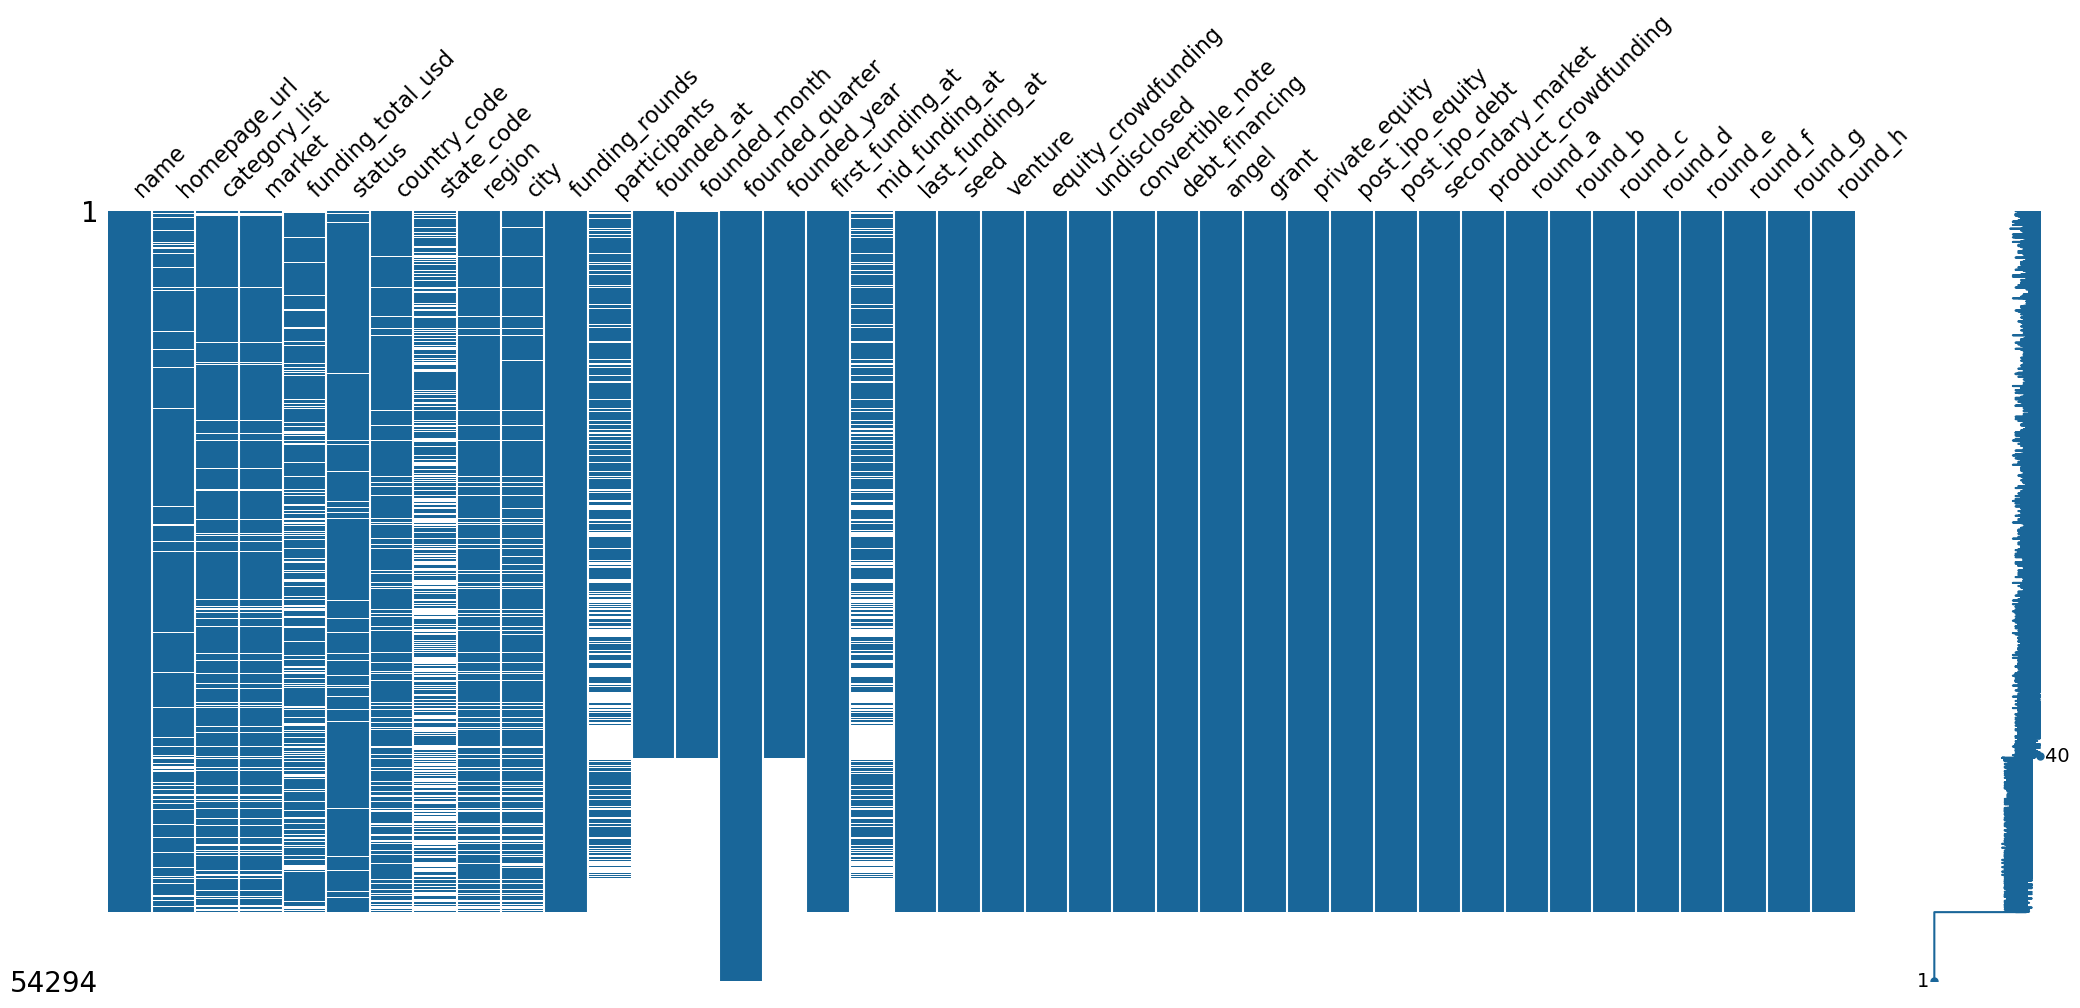

In [22]:
# Посмотрим матрицу пропусков при помощи библиотеки missingno
msno.matrix(
    df_investments, 
    color=(0.1, 0.4, 0.6)
);

Данных очень много, достаточное количество пропусков. Выведем тепловую карту и попробуем выявить взаимосвязь.

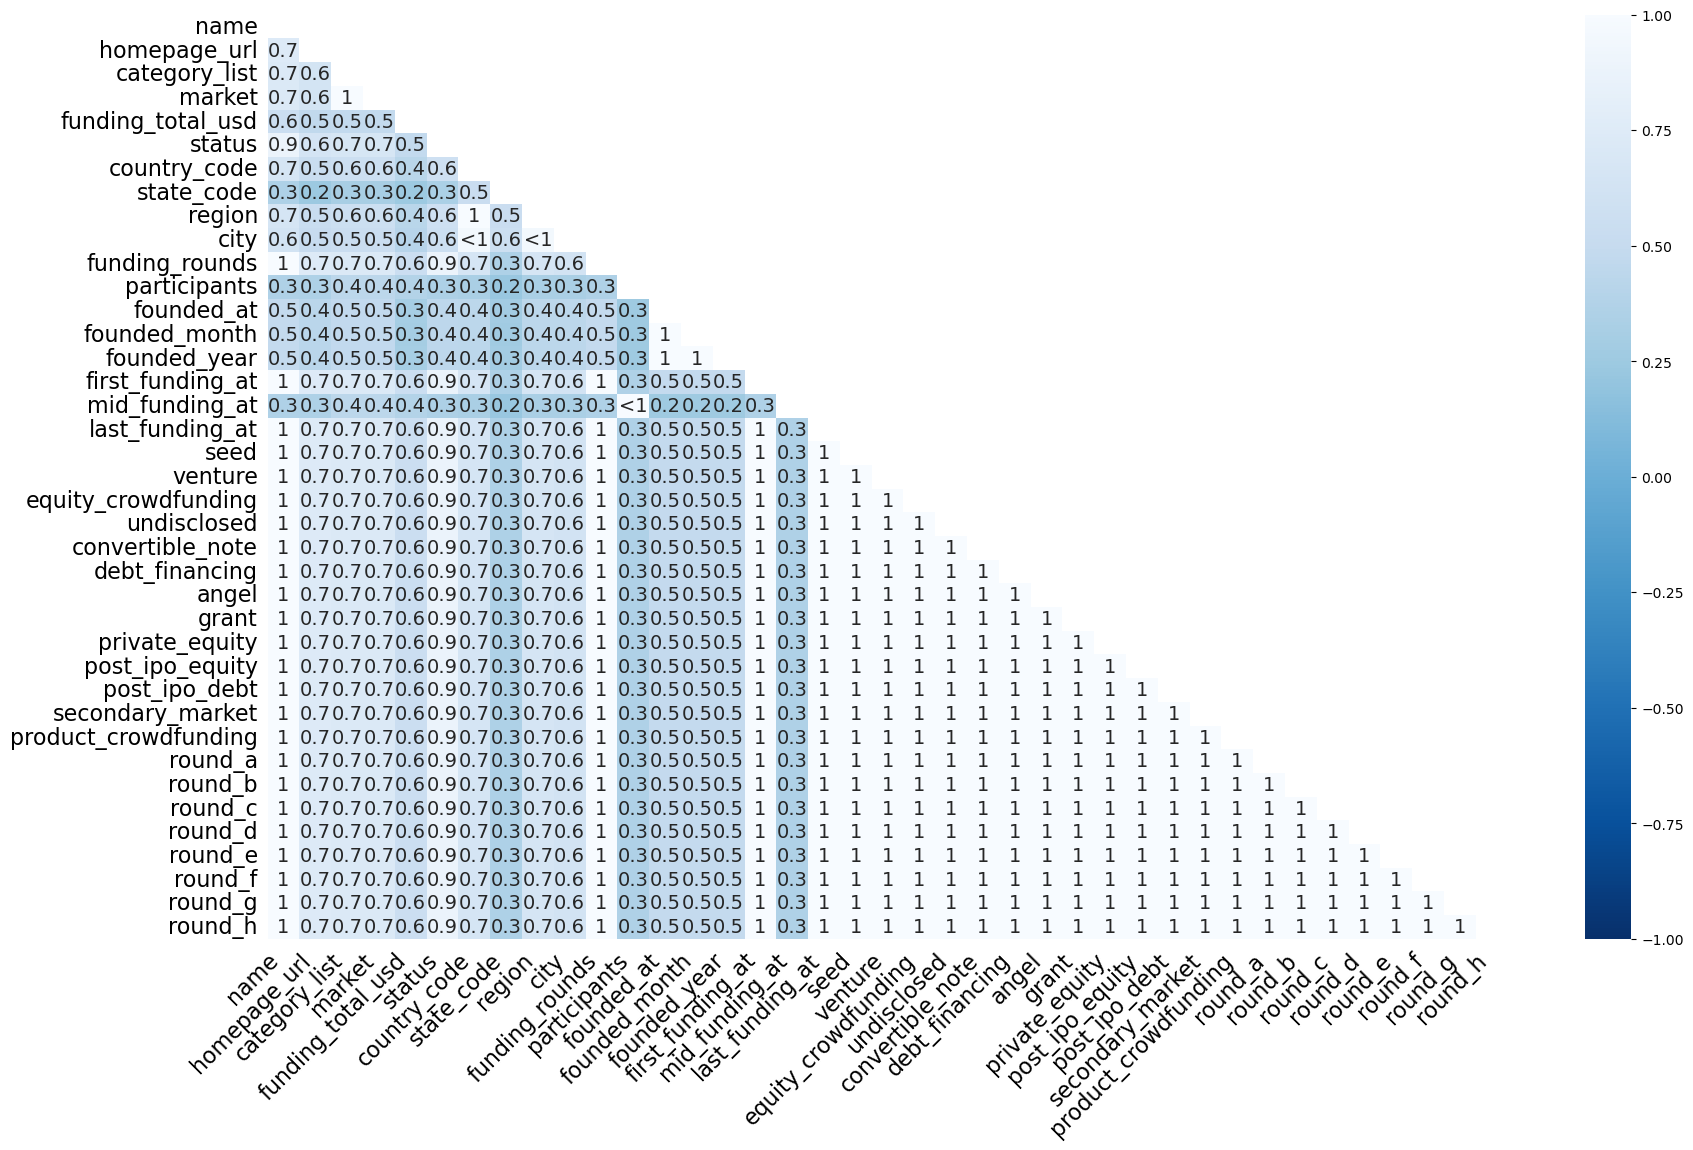

In [23]:
# Тепловая карта пропусков для df_investments
msno.heatmap(df_investments, cmap='Blues_r');

Некоторые пропуски в одних столбцах соответствуют пропускам в других столбцах, для примера:
* `category_list` - `market`;
* `country_code` - `region` - `city`;
* `participants` - `mid_funding_at`.

Наблюдается отсутствие дат.
Пропуски в значениях `mid_funding_at` заполним на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмём приблизительно середину интервала между этими двумя датами.

In [24]:
# Заменим пропуски в значениях mid_funding_at
mid_dates = (df_investments['first_funding_at'] + (df_investments['last_funding_at'] - df_investments['first_funding_at']) / 2)

df_investments['mid_funding_at'] = (df_investments['mid_funding_at'].fillna(mid_dates))

Заполним `founded_month` из дат по значениям `founded_at`.

In [25]:
# Вытянем месяц из founded_at
df_investments['founded_month'] = df_investments['founded_at'].dt.to_period('M')

Поработаем со столбцом `funding_total_usd`.

In [26]:
# Заполним пропуски NaN в funding_total_usd на основе сумм
df_investments['funding_total_usd'] = df_investments['funding_total_usd'].fillna(
    df_investments['seed'] + df_investments['venture'] + df_investments['equity_crowdfunding'] + 
    df_investments['undisclosed'] + df_investments['convertible_note'] + df_investments['debt_financing'] +
    df_investments['angel'] + df_investments['grant'] + df_investments['private_equity'] +
    df_investments['post_ipo_equity'] + df_investments['post_ipo_debt'] + df_investments['secondary_market'] + 
    df_investments['product_crowdfunding'])

In [27]:
# Удаляем строки столбца funding_total_usd с нулевыми значениями
df_investment = df_investments[df_investments['funding_total_usd'] != 0.0]

In [28]:
# Перезаписываем датасет и обновляем индексы
df_investments = df_investment.copy()
df_investments.reset_index(drop=True, inplace=True)

Доля пропусков в столбцах инвестиций, финансирований примерно составляет 9%. Эти пропуски зависят от названия компаний(`name`). Могли быть вызваны при сбое, при неправильном заполнении данных либо при отсутсвии данных в целом. Удалим эти строки по столбцу `name`.

In [29]:
# Удаляем строки по пропускам столбца name
df_investments.dropna(subset=['name'], inplace=True)


Посмотрим на датасет после замен и удалений на основе столбцов.

In [30]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40906 entries, 0 to 40906
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  object        
 1   homepage_url          38592 non-null  object        
 2   category_list         38403 non-null  object        
 3   market                38403 non-null  category      
 4   funding_total_usd     40906 non-null  float64       
 5   status                39801 non-null  category      
 6   country_code          37088 non-null  category      
 7   state_code            25619 non-null  category      
 8   region                37088 non-null  object        
 9   city                  36402 non-null  object        
 10  funding_rounds        40906 non-null  float32       
 11  participants          27331 non-null  float32       
 12  founded_at            32199 non-null  datetime64[ns]
 13  founded_month        

In [31]:
# Применяем метод isna() к датаcету df_investments
df_investments.isna().sum().sort_values()

name                        0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
equity_crowdfunding         0
post_ipo_debt               0
product_crowdfunding        0
round_a                     0
round_b                     0
round_c                     0
round_d                     0
round_e                     0
round_f                     0
secondary_market            0
venture                     0
seed                        0
last_funding_at             0
funding_total_usd           0
round_g                     0
funding_rounds              0
round_h                     0
founded_quarter             0
mid_funding_at              1
first_funding_at            2
status                   1105
homepage_url             2314
market                   2503
category_list            2503
region                   3818
country_co

In [32]:
# Посчитаем долю строк с пропусками
df_investments.isna().mean().sort_values()

name                    0.000000
undisclosed             0.000000
convertible_note        0.000000
debt_financing          0.000000
angel                   0.000000
grant                   0.000000
private_equity          0.000000
post_ipo_equity         0.000000
equity_crowdfunding     0.000000
post_ipo_debt           0.000000
product_crowdfunding    0.000000
round_a                 0.000000
round_b                 0.000000
round_c                 0.000000
round_d                 0.000000
round_e                 0.000000
round_f                 0.000000
secondary_market        0.000000
venture                 0.000000
seed                    0.000000
last_funding_at         0.000000
funding_total_usd       0.000000
round_g                 0.000000
funding_rounds          0.000000
round_h                 0.000000
founded_quarter         0.000000
mid_funding_at          0.000024
first_funding_at        0.000049
status                  0.027013
homepage_url            0.056569
market    

После данных шагов остались пропуски в некоторых столбцах, но они не нужны будут для дальнейшего анализа. Оставляем так, поработает ещё с дубликатами.

На данный момент в датасете осталось 40906 строк, изначально было 54294. Удалено ~24,66%.

#### Работа с дубликатами

In [33]:
# Посчитаем общее количество строк до обработки дубликатов
total_rows = len(df_investments)
print(f'Общее количество строк: {total_rows}')

Общее количество строк: 40906


In [34]:
# Проверим явные дубликаты в датасете merged_df
df_investments.duplicated().sum()

np.int64(0)

Предположим неявные дубликаты. Это могут быть по названию фирмы, сумме инвестиций

In [35]:
# Проверим неявные дубликаты по названию фирмы и сумме инвестиций
df_investments.duplicated(subset=['name','funding_total_usd']).sum()

np.int64(11)

In [36]:
# Покажем эти значения и сравним
df_investments[df_investments.duplicated(subset=['name', 'funding_total_usd'], keep=False)].sort_values('name', ascending=False)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
25584,vive,http://vive.me,|social network media|communities|iphone|video...,curated web,1500000.0,operating,deu,NaN,hanover,hanover,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3802,vive,NaN,|healthcare services|parenting|,parenting,1500000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6654,treasure valley urology services,NaN,|biotechnology|,biotechnology,332194.0,operating,usa,tx,austin,austin,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6980,treasure valley urology services,NaN,NaN,NaN,332194.0,operating,usa,tx,austin,austin,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25540,realync,http://www.realync.com,|real estate|,real estate,300000.0,operating,usa,il,chicago,chicago,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27830,realync,http://www.realync.com,|mobile|video|real estate|real time|,real time,300000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
31280,quest app,http://questapp.co,|curated web|,curated web,500000.0,operating,usa,ca,sf bay area,san francisco,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28856,quest app,http://questapp.co/,|sms|android|iphone|mobile|,android,500000.0,operating,usa,ca,sf bay area,san francisco,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40888,prysm,http://www.prysm.com/,NaN,NaN,293080123.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7765,prysm,http://www.prysm.com,|displays|hardware + software|,hardware + software,293080123.0,operating,usa,ca,sf bay area,san jose,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Изучив данные строки видно, что они являются дубликатами. Удалим их.

In [37]:
# Удалим дубликаты
df_investments.drop_duplicates(subset=['name', 'funding_total_usd'], inplace=True)

In [38]:
# Проверим количество строк после удаления дубликатов
total_rows = len(df_investments)
print(f'Общее количество строк: {total_rows}')

Общее количество строк: 40895


**Предобработка данных завершена.**

### Промежуточный вывод

После обработки в датасете `df_investments` осталось 40895 строк и 22 столбца.

Были удалены дубликаты(11 строк).

Заменены пустые ячейки для `mid_funding_at`, `funding_total_usd`.

Удалена часть строк по пропускам и нулевым значениям в столбцах `name` и `funding_total_usd`.

В датасете `cb_returns` назначен столбец `year` индексом всего датасета.

Данные готовы для дальнейшего анализа.

In [39]:
# для примера найдём: есть ли дата последних инвестиций раньше даты первой инвестиции
last_date_anomalies = df_investments[
    (df_investments['last_funding_at'].notna()) &
    (df_investments['first_funding_at'].notna()) &
    (df_investments['last_funding_at'] < df_investments['first_funding_at'])
]
last_date_anomalies

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h


In [40]:
# для примера найдём: есть ли дата основания компании позже остальных дат с финансами
funding_cols = ['first_funding_at', 'mid_funding_at', 'last_funding_at']

found_date_anomalies = df_investments[
    df_investments['founded_at'].notna() &
    df_investments[funding_cols].notna().any(axis=1) &  # есть хотя бы одна дата финансирования
    (
        (df_investments['founded_at'] > df_investments['first_funding_at']) |
        (df_investments['founded_at'] > df_investments['mid_funding_at']) |
        (df_investments['founded_at'] > df_investments['last_funding_at'])
    )
]
found_date_anomalies[['first_funding_at', 'mid_funding_at', 'last_funding_at', 'founded_at']]

,first_funding_at,mid_funding_at,last_funding_at,founded_at
552,1984-01-01,1984-01-01 00:00:00,1984-01-01,1984-08-12
1193,1993-09-23,1993-09-23 00:00:00,1993-09-23,1993-09-27
1197,1990-11-30,1997-04-30 12:00:00,2003-09-30,1994-01-01
1507,1995-01-01,1995-01-01 00:00:00,1998-01-01,1996-01-01
1745,1996-01-01,1999-03-01 00:00:00,1999-03-01,1996-04-01
...,...,...,...,...
32187,2014-10-07,2014-10-07 00:00:00,2014-10-07,2014-10-10
32189,2014-09-04,2014-09-04 00:00:00,2014-09-04,2014-10-17
32191,2014-10-20,2014-10-20 00:00:00,2014-10-20,2014-10-21
32198,2014-09-24,2014-09-24 00:00:00,2014-09-24,2014-11-26


В датасете достаточно много строк(2199 штук), где дата основания указана позже от дат инвестиций. Вряд ли эти компании получали финансовую подушку до основания, но мы не будем убирать эти значения из дальнейшего анализа.

## 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* единичное финансирование — был всего один раунд финансирования;
* срок финансирования до года — между первым и последним раундом финансирования прошло не более года;
* срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* по количеству компаний;
* по объёму инвестиций.

In [41]:
# Создадим группы по сроку финансирования

def dur_groups(row):
    # Если нет данных о датах — возвращаем «Нет информации»
    if pd.isna(row['first_funding_at']) or pd.isna(row['last_funding_at']):
        return 'Нет информации'
    
    # 1. Единичное финансирование (1 раунд)
    if row['funding_rounds'] == 1:
        return 'Единичное'
    
    # 2. Срок между первым и последним раундом
    duration = row['last_funding_at'] - row['first_funding_at']
    
    if duration <= timedelta(days=365):  # до 1 года включительно
        return 'До года'
    else:  # более 1 года
        return 'Более года'

# Применяем функцию
df_investments['duration_group'] = df_investments.apply(dur_groups, axis=1)

Покажем данные группы по количеству компаний.

In [42]:
# Посчитаем количество компаний по выделенным группам
duration_groups = df_investments[df_investments['duration_group'] != 'Нет информации'].groupby('duration_group')['name'].count().sort_values(ascending=False)
duration_groups

duration_group
Единичное     24103
Более года    12290
До года        4500
Name: name, dtype: int64

In [43]:
# Посмотрим в относительных значениях, переведём в проценты
ratio_duration_groups = round(duration_groups/duration_groups.sum()*100, 2)
ratio_duration_groups

duration_group
Единичное     58.94
Более года    30.05
До года       11.00
Name: name, dtype: float64

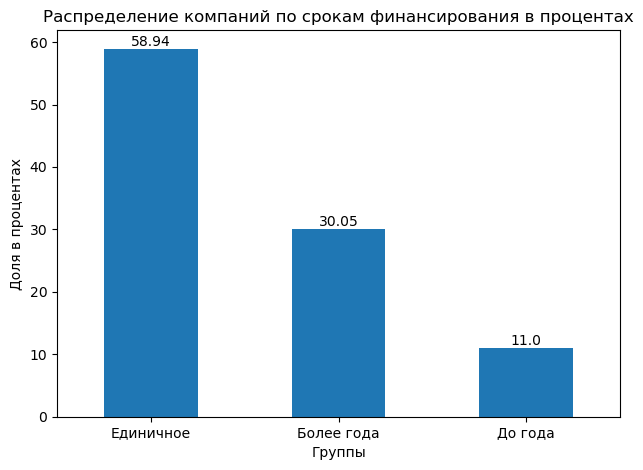

In [44]:
# Строим столбчатую диаграмму в процентном соотношении
ratio_duration_groups.plot(kind='bar')

plt.title('Распределение компаний по срокам финансирования в процентах')
plt.xlabel('Группы')
plt.ylabel('Доля в процентах')
plt.xticks(rotation=0)

# Добавим подписи на столбцы
for i, v in enumerate(ratio_duration_groups):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Покажем данные группы по объёму инвестиций.

In [45]:
# Посчитаем объём инвестиций по выделенным группам
duration_groups_sum = df_investments[df_investments['duration_group'] != 'Нет информации'].groupby('duration_group')['funding_total_usd'].sum().sort_values(ascending=False)
pd.set_option('display.float_format', '{:.2f}'.format)
duration_groups_sum

duration_group
Более года   402706207604.00
Единичное    198997137636.00
До года       48885731057.00
Name: funding_total_usd, dtype: float64

In [46]:
# Посмотрим в относительных значениях, переведём в проценты
ratio_duration_groups_sum = round(duration_groups_sum/duration_groups_sum.sum()*100, 2)
ratio_duration_groups_sum

duration_group
Более года   61.90
Единичное    30.59
До года       7.51
Name: funding_total_usd, dtype: float64

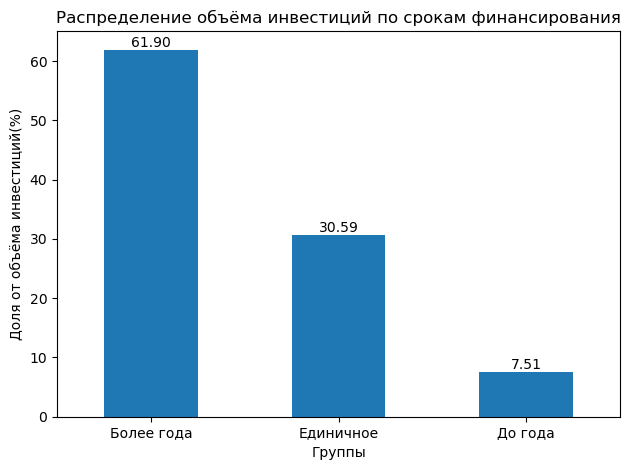

In [47]:
# Строим столбчатую диаграмму в процентном соотношении
ratio_duration_groups_sum.plot(kind='bar')

plt.title('Распределение объёма инвестиций по срокам финансирования')
plt.xlabel('Группы')
plt.ylabel('Доля от объёма инвестиций(%)')
plt.xticks(rotation=0)

# Добавим подписи на столбцы
for i, v in enumerate(ratio_duration_groups_sum):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

В разрезе количества компаний:
* больше всего компаний с одним раундом финансирования - 24103 (58.94%);
* со срокам более года - 12290 компаний (30.05%);
* менее года было 4500 компаний (11.0%)

По инвестициям: 
* больше всего инвестиций получили компании со сроком финансирования более года - 61.90% от общего объёма;
* менее года - 7.51% от общего объёма инвестиций;
* с однима раундом получили 30.59% инвестиций.

In [48]:
# Создадим карту цветов
color_map = {
    'Единичное': 'blue',      
    'До года': 'green',      
    'Более года': 'red',     
    'Нет информации': 'yellow'             
}

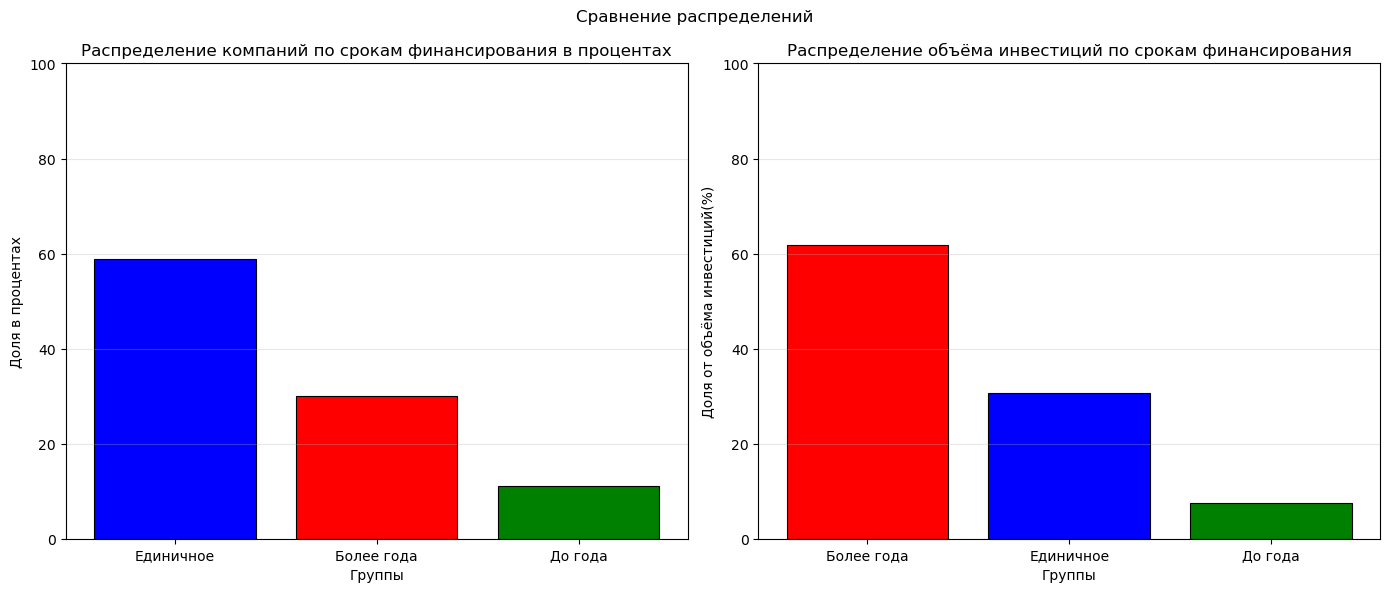

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Левый график: ratio_duration_groups
ax1.bar(
    ratio_duration_groups.index,
    ratio_duration_groups.values,
    color=[color_map.get(cat, '#7f7f7f') for cat in ratio_duration_groups.index], 
    edgecolor='black',
    linewidth=0.8
)
ax1.set_title('Распределение компаний по срокам финансирования в процентах')
ax1.set_ylabel('Доля в процентах')
ax1.set_xlabel('Группы')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 100)  # проценты от 0 до 100


# Правый график: ratio_duration_groups_sum
ax2.bar(
    ratio_duration_groups_sum.index,
    ratio_duration_groups_sum.values,
    color=[color_map.get(cat, '#7f7f7f') for cat in ratio_duration_groups_sum.index],
    edgecolor='black',
    linewidth=0.8
)
ax2.set_title('Распределение объёма инвестиций по срокам финансирования')
ax2.set_ylabel('Доля от объёма инвестиций(%)')
ax2.set_xlabel('Группы')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 100)


# Общая подпись
plt.suptitle('Сравнение распределений')
plt.tight_layout()
plt.show()

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`, разделить на категории:

* массовый(более 120 компаний);
* средний(от 35 до 120 компаний);
* нишевый(менее 35 компаний).

In [50]:
df_investments['market'] = df_investments['market'].astype('category')

market_counts = df_investments['market'].value_counts().reset_index()
market_counts.columns = ['market', 'market_count']

# Гарантируем числовой тип. 
market_counts['market_count'] = pd.to_numeric(market_counts['market_count'], errors='coerce')

# Обрабатываем пропуски (если to_numeric нашёл мусор и сделал NaN)
if market_counts['market_count'].isna().any():
    print(f"Найдено {market_counts['market_count'].isna().sum()} некорректных значений. Заполняем нулями.")
    market_counts['market_count'] = market_counts['market_count'].fillna(0).astype(int)

def cat_segment(count):
    if count > 120:
        return 'массовый'
    elif 35 <= count <= 120:
        return 'средний'
    else:
        return 'нишевый'

market_counts['segment_category'] = market_counts['market_count'].apply(cat_segment)

df_investments = df_investments.merge(market_counts, on='market', how='left')

In [51]:
# Посчитаем количество сегментов по типу
market_counts_segment = (
    market_counts
    .groupby('segment_category')
    .size()  # считает количество строк в группе
    .sort_values(ascending=False)
)
market_counts_segment

segment_category
нишевый     334
средний      57
массовый     48
dtype: int64

In [52]:
# Посмотрим в относительных значениях, переведём в процентцы
ratio_market_counts_segment = round(market_counts_segment/market_counts_segment.sum()*100, 2)
ratio_market_counts_segment

segment_category
нишевый    76.08
средний    12.98
массовый   10.93
dtype: float64

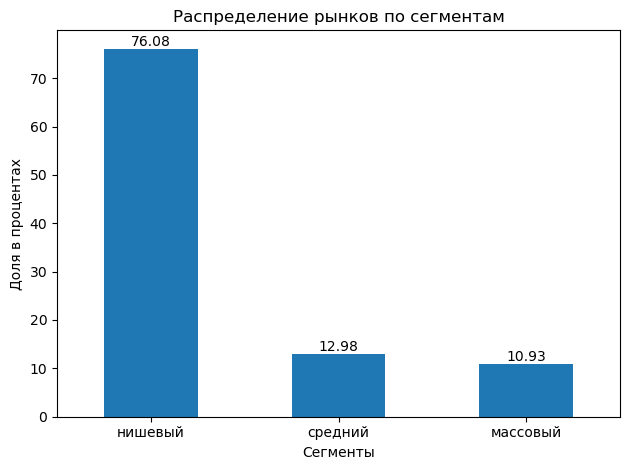

In [53]:
# Строим столбчатую диаграмму в процентном соотношении
ratio_market_counts_segment.plot(kind='bar')

plt.title('Распределение рынков по сегментам')
plt.xlabel('Сегменты')
plt.ylabel('Доля в процентах')
plt.xticks(rotation=0)

# Добавим подписи на столбцы
for i, v in enumerate(ratio_market_counts_segment):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

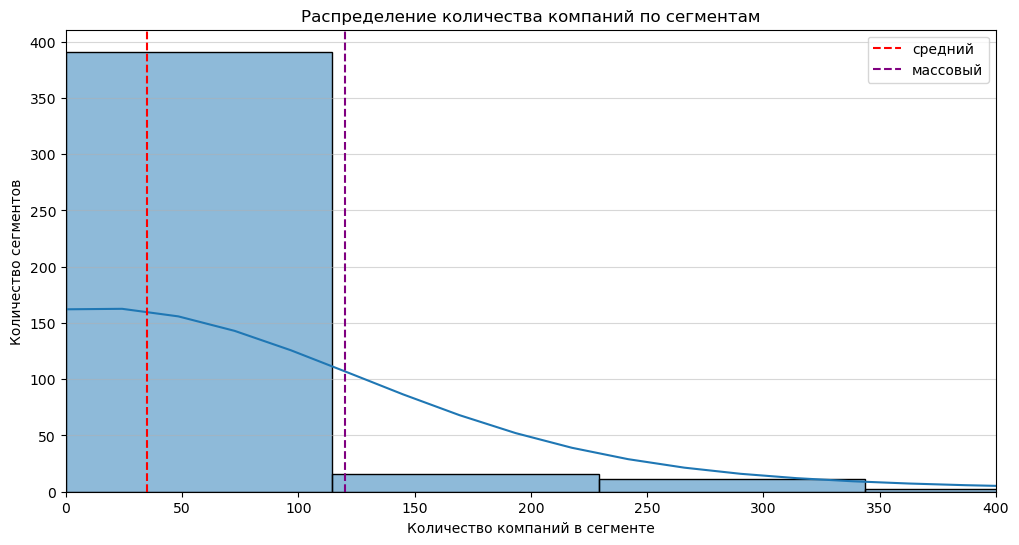

In [54]:
plt.figure(figsize=(12, 6))

sns.histplot(
    market_counts.values,
    kde = True
)

plt.title('Распределение количества компаний по сегментам')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.axvline(x=35, color='red', linestyle='--', label='средний')
plt.axvline(x=120, color='purple', linestyle='--', label='массовый')
plt.xlim(0, 400)
plt.grid(axis='y', alpha=0.5)
plt.legend()

plt.show()

In [55]:
# Посчитаем количество записей по рынкам в категориях сегментов
segment_counts = df_investments.groupby('segment_category')['market'].value_counts()
segment_counts

segment_category  market          
массовый          software            4812
                  biotechnology       3590
                  mobile              2343
                  e-commerce          1866
                  curated web         1691
                                      ... 
средний           web tools              0
                  weddings               0
                  wholesale              0
                  wine and spirits       0
                  women                  0
Name: count, Length: 1317, dtype: int64

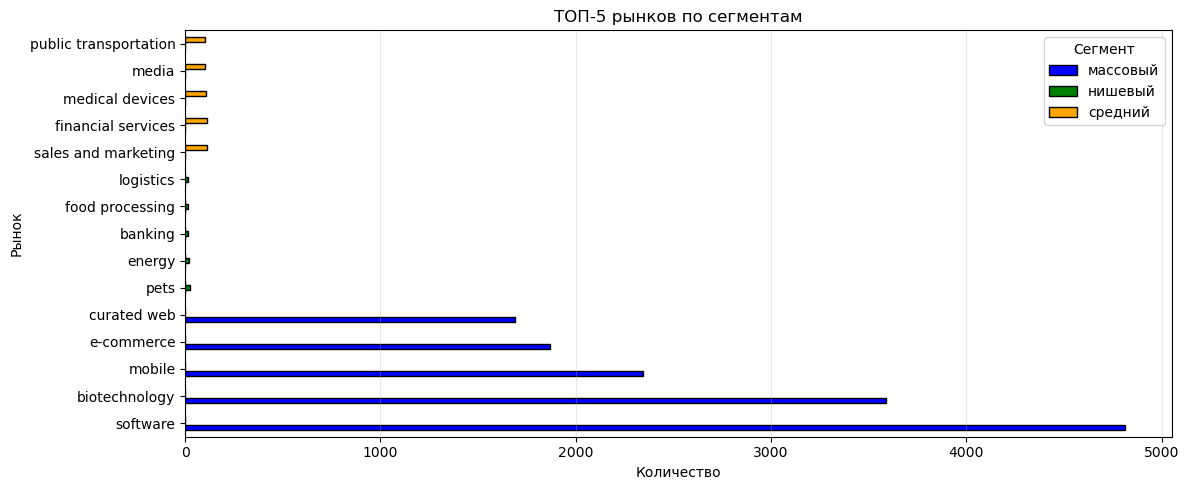

In [56]:
# Сделаем выборку ТОП-5 в каждой категории сегментов
top_markets = segment_counts.groupby('segment_category').head(5)

# Преобразуем в удобный формат для графика
plot_data = top_markets.unstack('segment_category').fillna(0)

# Строим график
plot_data.plot.barh(
    figsize=(12, 5),
    color=['blue', 'green', 'orange'],
    edgecolor='black'
)
plt.title('ТОП‑5 рынков по сегментам')
plt.xlabel('Количество')
plt.ylabel('Рынок')
plt.legend(title='Сегмент')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

В нишевый сегмент входит 76.08% от общего количества рынков, в ТОП-5 входят такие рынки, как `pets`, `energy`, `banking`, `food processing`, `logistics`. Этот сегмент отличается от других мелкой конкуренцией внутри одного рынка.

В средний попало 12.98% от общего числа рынков. В лидерах - `sales and marketing`, `financial services`, `medical devices`. Конкуренция здесь не так высока.

Массовый сегмент отличается очень высокой конкуренцией. В ТОП сегмента вошли рынки `software`, `biotechnology`, `mobile`. Доля всего сегмента - 10.93%.

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` - для нишевых и `mid` - для средних.

In [57]:
# Создаем копию датасета
df_investments_segm = df_investments.copy()

In [58]:
# Заменяем значения в столбце market
df_investments['market'] = df_investments.apply(
    lambda row: 
        row['market'] if row['segment_category'] == 'массовый'
        else 'mid' if row['segment_category'] == 'средний'
        else 'niche',
    axis=1
)

# Выведем уникальные значения для проверки преобразований
df_investments['market'].unique()

array(['education', 'niche', 'mid', 'social media', 'hardware + software',
       'biotechnology', 'hospitality', 'enterprise software',
       'manufacturing', 'finance', 'design', 'nonprofits', 'software',
       'curated web', 'health care', 'health and wellness',
       'clean technology', 'web hosting', 'e-commerce', 'automotive',
       'medical', 'fashion', 'security', 'networking', 'analytics',
       'semiconductors', 'public relations', 'travel', 'consulting',
       'real estate', 'technology', 'music', 'advertising', 'games',
       'mobile', 'internet', 'sports', 'photography', 'news', 'search',
       'messaging', 'video', 'marketplaces', 'entertainment', 'saas',
       'cloud computing', 'big data', 'apps', 'social network media',
       'startups'], dtype=object)

In [59]:
# Группируем по категориям
segment_stats = market_counts.groupby('segment_category').agg(
    market_count=('market_count', 'sum'),   # Сумма компаний в сегменте
    num_markets=('market', 'count')        # Количество рынков (строк) в сегменте
).reset_index()

# Рассчитываем долю компаний в каждом сегменте (в %)
total_companies = segment_stats['market_count'].sum()
segment_stats['share_companies'] = (segment_stats['market_count'] / total_companies * 100).round(1)

print(segment_stats)

  segment_category  market_count  num_markets  share_companies
0         массовый         33728           48            87.80
1          нишевый           829          334             2.20
2          средний          3839           57            10.00


In [60]:
segment_stats

,segment_category,market_count,num_markets,share_companies
0,массовый,33728,48,87.80
1,нишевый,829,334,2.20
2,средний,3839,57,10.00


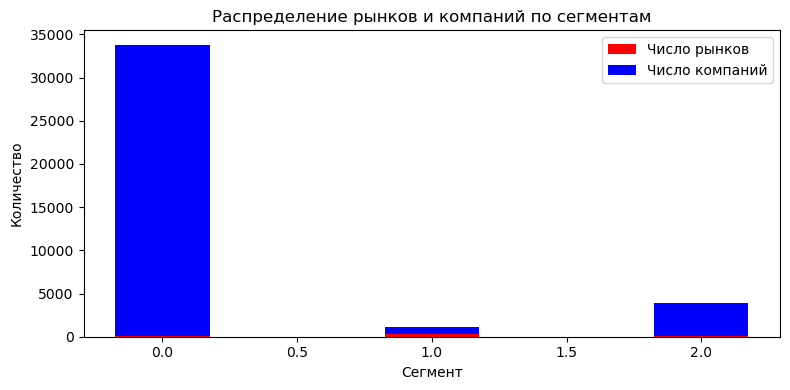

In [61]:
# Построим наглядный график
fig2, ax2 = plt.subplots(figsize=(8, 4))


x = segment_stats.index
y1 = segment_stats['num_markets']    
y2 = segment_stats['market_count']

width = 0.35
ax2.bar(x, y1, width, label='Число рынков', color='red')
ax2.bar(x, y2, width, bottom=y1, label='Число компаний', color='blue')


ax2.set_xlabel('Сегмент')
ax2.set_ylabel('Количество')
ax2.set_title('Распределение рынков и компаний по сегментам')
ax2.legend()


plt.tight_layout()
plt.show()

Массовые сегменты — малочисленны, но стратегически важны. Количество компаний, задействованных в этих сегментах 33728, что составляет наибольший процент от всех компаний и равнется 87.80%.

Массовые сегменты несмотря на долю в 12.18%(количестве рынков всего 48) от разделённых сегментов, они задают тренды рынка. Ниже рассмторим массовый сегмент.

In [62]:
# Рассмотрим массовый сегмент отдельно, разобьём на подгруппы
massive_segment = market_counts[market_counts['segment_category'] == 'массовый'].copy()

bins = [121, 150, 200, 300, 500, 1000, np.inf]
labels = ['121–150', '151–200', '201–300', '301–500', '501–1000', '>1000']


massive_segment['size_group'] = pd.cut(massive_segment['market_count'], bins=bins, labels=labels, right=False)

grouped = massive_segment['size_group'].value_counts().sort_index()

massive_segment

,market,market_count,segment_category,size_group
0,software,4812,массовый,>1000
1,biotechnology,3590,массовый,>1000
2,mobile,2343,массовый,>1000
3,e-commerce,1866,массовый,>1000
4,curated web,1691,массовый,>1000
5,enterprise software,1381,массовый,>1000
6,health care,1185,массовый,>1000
7,clean technology,1180,массовый,>1000
8,games,1117,массовый,>1000
9,advertising,1107,массовый,>1000


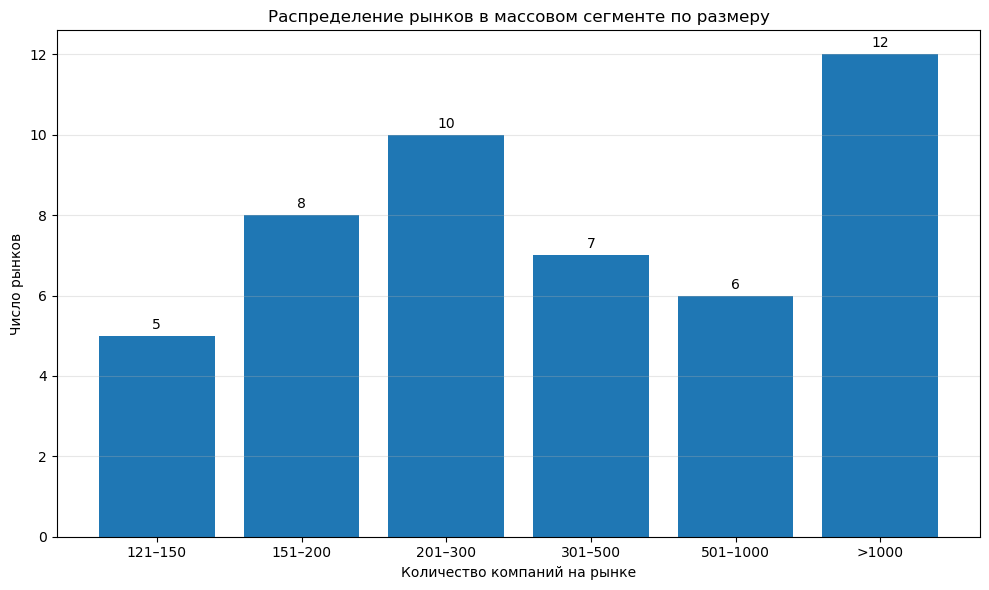

In [63]:
# Строим график
plt.figure(figsize=(10, 6))
bars = plt.bar(grouped.index, grouped.values)
plt.title('Распределение рынков в массовом сегменте по размеру')
plt.xlabel('Количество компаний на рынке')
plt.ylabel('Число рынков')

plt.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, grouped.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
              f'{count}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
plt.show()

В массовом сегменте находится 48 рынков.

ТОП-5 по количеству компаний(более 1000 компаний):
* `software` - 4812;
* `biotechnology` - 3590;
* `mobile` - 2343;
* `e-commerce` - 1866;
* `curated web` - 1691.

В массовом сегменте мало рынков, но они концентрируют значительное число компаний.

## 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

In [64]:
# Выведем основные метрики столбца funding_total_usd
df_investments['funding_total_usd'].describe()

count         40895.00
mean       15909606.95
std       168697811.63
min               1.00
25%          350000.00
50%         2000000.00
75%        10000000.00
max     30079503000.00
Name: funding_total_usd, dtype: float64

Среднее около 16 млн, медиана 2 млн. Видим высокое стандартное отклонение.

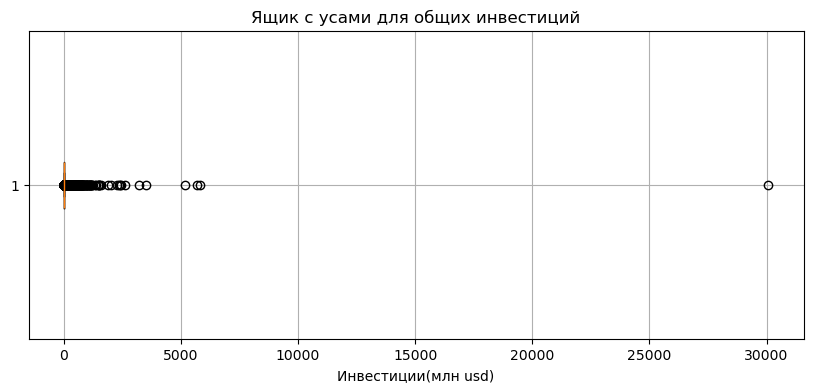

In [65]:
# Создаём ящик с усами по столбцу funding_total_usd
plt.figure(figsize=(10, 4))
plt.boxplot(df_investments['funding_total_usd'], vert=False, showmeans=False)

def format_billions(value, tick_number):
    return f'{value/1e6:.0f}'

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_billions))

plt.title('Ящик с усами для общих инвестиций')
plt.xlabel('Инвестиции(млн usd)')
plt.grid()

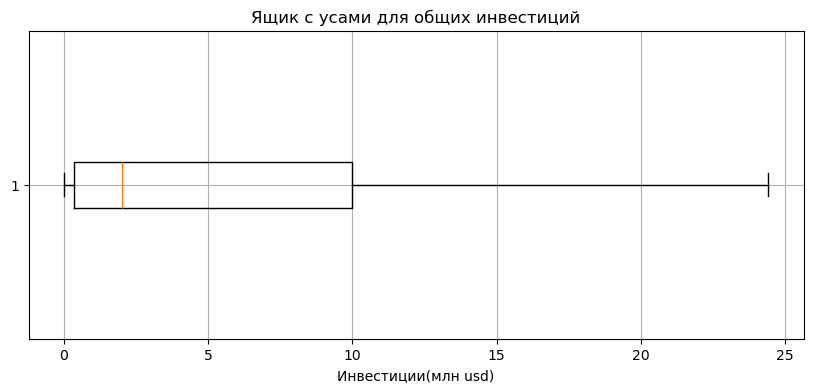

In [66]:
# Создаем график с усами по столбцу funding_total_usd без выбросов
plt.figure(figsize=(10, 4))
plt.boxplot(df_investments['funding_total_usd'], vert=False, showmeans=False, showfliers=False)

def format_billions(value, tick_number):
    return f'{value/1e6:.0f}'

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_billions))

plt.title('Ящик с усами для общих инвестиций')
plt.xlabel('Инвестиции(млн usd)')
plt.grid()

На основе данных можно сделать вывод, что диапазон размаха общих инвестиций для одной компании находится в промежутке от 0 до 24.5 млн USD

Определим компании с аномальным объёмом общего финансирования(используем метод IQR отдельно по каждому сегменту).

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем ТОП таких сегментов.

In [67]:
subset = df_investments[['name', 'market', 'funding_total_usd']].dropna(subset=['funding_total_usd'])


def anomal_robust(group):
    if len(group) < 4:
        # Возвращаем пустой DataFrame с нужными столбцами
        return pd.DataFrame(columns=['name', 'market', 'funding_total_usd'])
    
    funding = group['funding_total_usd']
    Q1 = funding.quantile(0.25)
    Q3 = funding.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (funding < lower_bound) | (funding > upper_bound)

    result = group[mask][['name', 'funding_total_usd']].copy()
    result['market'] = group.name
    return result[['name', 'market', 'funding_total_usd']]

# Создаём anomal_comp с исправленной функцией
anomal_comp = subset.groupby('market').apply(
    anomal_robust,
    include_groups=False
).reset_index(drop=True)

In [68]:
# Используем метод IQR
def iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

In [69]:
# Найдём выбросы и общее количество записей
out_market = df_investments.groupby('market').apply(
    lambda x: iqr(x['funding_total_usd']),
    include_groups=False
)
total_usd_market = df_investments.groupby('market')['funding_total_usd'].count()

# Рассчитаем долю аномалий, выведем первые 20 в порядке убывания
out_count = out_market.groupby('market').size()
out_ratio = (out_count / total_usd_market * 100).fillna(0).sort_values(ascending=False).reset_index()
top_ratio = out_ratio.head(20)
top_ratio

,market,funding_total_usd
0,real estate,17.20
1,entertainment,16.67
2,consulting,16.62
3,search,16.49
4,cloud computing,16.45
5,saas,16.18
6,photography,16.18
7,technology,15.97
8,video,15.96
9,travel,15.45


In [70]:
# Рассмотрим для сегментов
out_segment = df_investments.groupby('segment_category').apply(lambda x: iqr(x['funding_total_usd']),include_groups=False)
total_usd_segment = df_investments.groupby('segment_category')['funding_total_usd'].count()

out_count = out_segment.groupby('segment_category').size()

# Рассчитаем долю аномалий по сегментам
out_ratio_segm = (out_count / total_usd_segment * 100).fillna(0).sort_values(ascending=False).reset_index()
out_ratio_segm

,segment_category,funding_total_usd
0,нишевый,15.92
1,средний,14.48
2,массовый,13.01


В ТОП-5 по долям аномальных инвестиций входят:
* `real estate`;
* `entertainment`;
* `consulting`;
* `search`;
* `cloud computing`.

В разрезе ранее определённых сегментов доли аномальных значений в нишевом составляют 15.92%, в среднем - 14.48%, в массовом сегменте - 13.01%.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Построим визуализацию по году последнего финансирования с количеством компаний и сделаем вывод.

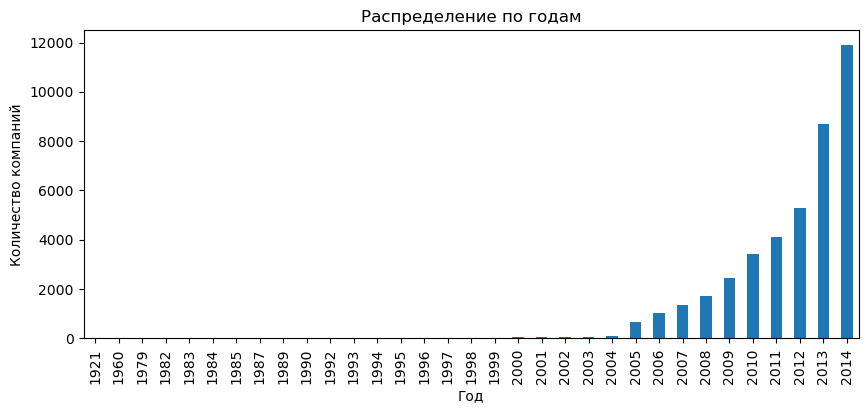

In [71]:
# График по годам
quantity_comp = df_investments['last_funding_at'].dt.year.value_counts().sort_index()
plt.figure(figsize=(10, 4))
quantity_comp.plot(kind='bar')
plt.title('Распределение по годам')
plt.xlabel('Год')
plt.ylabel('Количество компаний')

plt.show()

In [72]:
# Выведем количество компаний с последним финансированием в 2014
quantity_comp[2014]

np.int64(11907)

In [73]:
# Выведем количество основанных компаний в 2014
df_investments['founded_year'].value_counts()[2014]

np.int64(1014)

In [74]:
# Посмторим, какие данные имеются в датасете df_returns за 2014 
df_returns.loc[2014]

seed                    530.75
venture                7272.01
equity_crowdfunding       1.15
undisclosed             105.72
convertible_note          7.87
debt_financing         1017.75
angel                   293.98
grant                     0.00
private_equity          384.01
post_ipo_equity         262.70
post_ipo_debt            37.20
secondary_market          1.03
product_crowdfunding      0.72
Name: 2014, dtype: float32

В 2014 году было основаноо 1014 компаний, последнее финансирование в этом же году получили 11907 компаний. 
Это значительный объём информации. То есть 2014 год можно рассматривать, как год для анализа трендов.

По датасету `df_returns` в каждом столбце имеется информация, кроме столбца `grant`(тут ноль, но этот столбец отвечает за вовзраты по гранту, можно не учитывать его).

**Делаем вывод:** 2014 год можно рассматривать, как год для анализа трендов.

In [75]:
# Создадим маску для столбцов с датами за 2014 год
mask_2014 = (
    (df_investments['founded_at'].dt.year == 2014) |
    (df_investments['first_funding_at'].dt.year == 2014) |
    (df_investments['mid_funding_at'].dt.year == 2014) |
    (df_investments['last_funding_at'].dt.year == 2014)
)

date_df = df_investments[mask_2014].copy()


# Собираем все даты 2014 года в один ряд (исключая NaT)
all_dates_2014 = pd.concat([
    date_df['founded_at'].dropna(),
    date_df['first_funding_at'].dropna(),
    date_df['mid_funding_at'].dropna(),
    date_df['last_funding_at'].dropna()
])

all_dates_2014 = all_dates_2014[all_dates_2014.dt.year == 2014]

monthly_counts = all_dates_2014.dt.month.value_counts().sort_index()

monthly_counts = monthly_counts.reindex(range(1, 13), fill_value=0)

In [76]:
# Выведем количество дат по месяцам в 2014
monthly_counts

1     3137
2     2292
3     2521
4     2412
5     2266
6     2711
7     2656
8     2179
9     2245
10    2138
11    1348
12     100
Name: count, dtype: int64

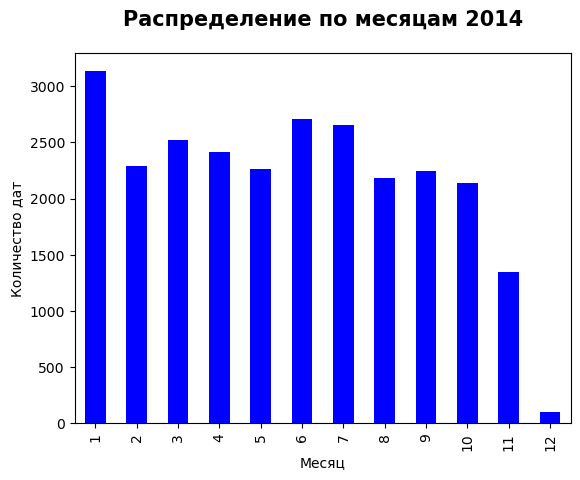

In [77]:
monthly_counts.plot(kind='bar', color='blue')
plt.title('Распределение по месяцам 2014',
          fontsize=15,
          fontweight='bold',
          pad=20)
plt.xlabel('Месяц')
plt.ylabel('Количество дат')

plt.show()

На основе визуализации можно сделать вывод, что за 2014 год для декабря месяца данные неполные.

Исключим аномальные компании.

In [78]:
# На основе ранее выделенных компаний с аномальными инвестициями удалим их
cleaned_inv_df = df_investments.merge(
    anomal_comp[['name', 'market']],
    on=['name', 'market'],
    how='left',
    indicator=True
)

cleaned_inv_df = cleaned_inv_df[cleaned_inv_df['_merge'] == 'left_only'].drop(columns='_merge')

In [79]:
# Покажем наглядно число строк
print(f"Исходное число записей: {len(df_investments)}")
print(f"После удалений число записей: {len(cleaned_inv_df)}")

Исходное число записей: 40895
После удалений число записей: 35678


На основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [80]:
# Получим года, по которым было зафиксировано 50 или более раундов финансирования
cleaned_inv_df['funding_year'] = cleaned_inv_df['mid_funding_at'].dt.year
yearly_rounds = cleaned_inv_df.groupby('funding_year')['funding_rounds'].sum().reset_index(name='total_rounds')
filtr_years = yearly_rounds[yearly_rounds['total_rounds'] >= 50]['funding_year'].tolist()

# Фильтруем исходный датасет: оставляем только компании, финансированные в эти годы
clean_df = cleaned_inv_df[cleaned_inv_df['funding_year'].isin(filtr_years)]

Отфильтруем, чтоб увидеть информацию по годам, которые попали в сортировку.

In [81]:
# Фильтруем yearly_rounds по отобранным годам и сортируем по году
filtered_rounds = yearly_rounds[yearly_rounds['funding_year'].isin(filtr_years)].sort_values('funding_year')

In [82]:
filtered_rounds

,funding_year,total_rounds
18,2000.00,112.00
19,2001.00,66.00
20,2002.00,98.00
21,2003.00,125.00
22,2004.00,181.00
23,2005.00,948.00
24,2006.00,1850.00
25,2007.00,2839.00
26,2008.00,3665.00
27,2009.00,4627.00


### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируемся на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

In [83]:
# Посчитаем суммы по типам инвестиций
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

total_amounts = clean_df[funding_types].sum().sort_values(ascending=False)
total_amounts

venture                129051954569.00
seed                     9433176919.00
debt_financing           8193778234.00
private_equity           4848725439.00
angel                    2477273836.00
undisclosed              2088889269.00
grant                    2002123688.00
post_ipo_equity          1930552068.00
convertible_note          566039424.00
post_ipo_debt             286718349.00
equity_crowdfunding       237960640.00
product_crowdfunding      183310288.00
secondary_market           45285796.00
dtype: float64

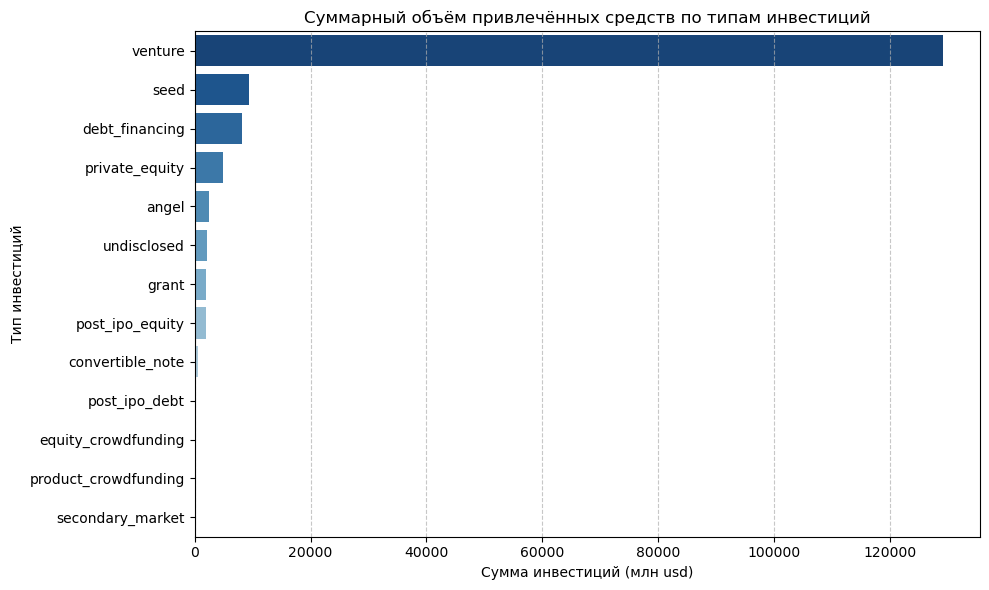

In [84]:
# Строим график по полученным данным
plt.figure(figsize=(10, 6))
plot_data = pd.DataFrame({
    'amount': total_amounts.values,
    'investment_type': total_amounts.index
})

sns.barplot(
    data=plot_data,
    x='amount',
    y='investment_type',
    hue='investment_type',  
    palette='Blues_r',
    legend=False  
)

def format_billions(value, tick_number):
    return f'{value/1e6:.0f}'

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_billions))
plt.title('Суммарный объём привлечённых средств по типам инвестиций')
plt.xlabel('Сумма инвестиций (млн usd)')
plt.ylabel('Тип инвестиций')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [85]:
# Посчитаем количество по типам инвестиций
counts_amounts = clean_df[funding_types].mask(clean_df[funding_types] == 0).count().sort_values(ascending=False)
counts_amounts

venture                 18834
seed                    13365
debt_financing           3269
angel                    2933
grant                    1005
undisclosed               814
private_equity            637
convertible_note          521
equity_crowdfunding       515
product_crowdfunding      204
post_ipo_equity           163
post_ipo_debt              27
secondary_market            7
dtype: int64

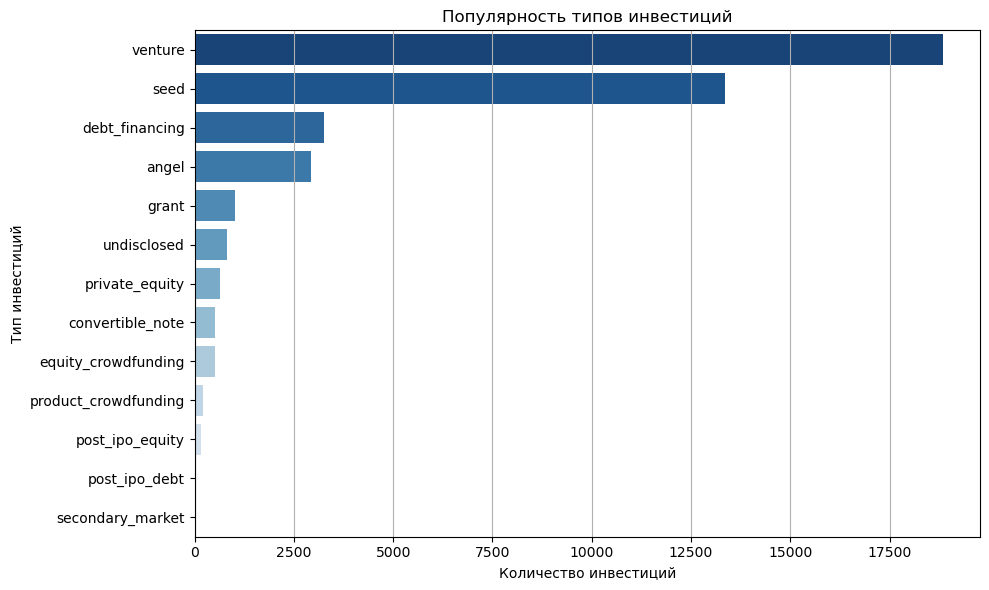

In [86]:
# Строим график по полученным данным
plt.figure(figsize=(10, 6))
plot_data = pd.DataFrame({
    'count': counts_amounts.values,
    'investment_type': counts_amounts.index
})

sns.barplot(
    data=plot_data,
    x='count',
    y='investment_type',
    hue='investment_type',
    palette='Blues_r',
    legend=False  
)

plt.title('Популярность типов инвестиций')
plt.xlabel('Количество инвестиций')
plt.ylabel('Тип инвестиций')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

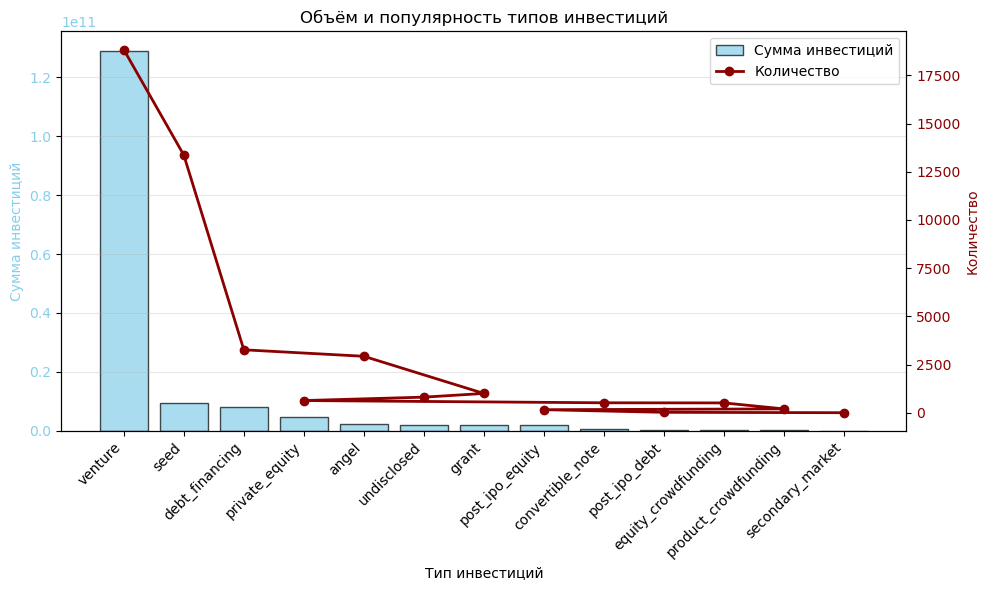

In [87]:
# Построим совместный график для наглядности
fig, ax1 = plt.subplots(figsize=(10, 6))


# График 1: суммы инвестиций (левая ось Y)
ax1.bar(
    total_amounts.index,
    total_amounts.values,
    alpha=0.7,
    color='skyblue',
    edgecolor='black',
    label='Сумма инвестиций'
)
ax1.set_xlabel('Тип инвестиций')
ax1.set_ylabel('Сумма инвестиций', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

ax1.set_title('Объём и популярность типов инвестиций')


# Вторая ось Y (правая) для количества инвестиций
ax2 = ax1.twinx()
ax2.plot(
    counts_amounts.index,
    counts_amounts.values,
    marker='o',
    color='darkred',
    linewidth=2,
    label='Количество'
)
ax2.set_ylabel('Количество', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')


# Легенда (объединяем легенды с обеих осей)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')


# Улучшаем читаемость подписей на оси X
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')


# Добавляем сетку (только для левой оси)
ax1.grid(True, axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

Наиболее часто используемые типы инвестиций и наиболее большие суммы инвестиций совпадают и выпадают на долю `venture`, `seed` и `debt_financing`.

`angel` хоть и часто использовали, но суммы инвестиций ниже, чем у первых трёх. - Несмотря на частое использование, общий объем финансирования значительно меньше, чем у Venture и Seed;

`post_ipo_equity` редко встречается, но имеет хороший мешок инвестиций.

В самом низу оказывается по двум показателям `secondary_market`.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [88]:
# Посчитаем суммы вовзратов
total_returns = df_returns[funding_types].sum().sort_values(ascending=False)
total_returns

venture                40578.62
debt_financing          4734.85
private_equity          3587.33
seed                    2382.24
angel                   1509.23
post_ipo_equity         1104.96
undisclosed              730.88
post_ipo_debt             91.03
convertible_note          34.79
secondary_market           5.20
equity_crowdfunding        3.83
product_crowdfunding       1.86
grant                      0.00
dtype: float32

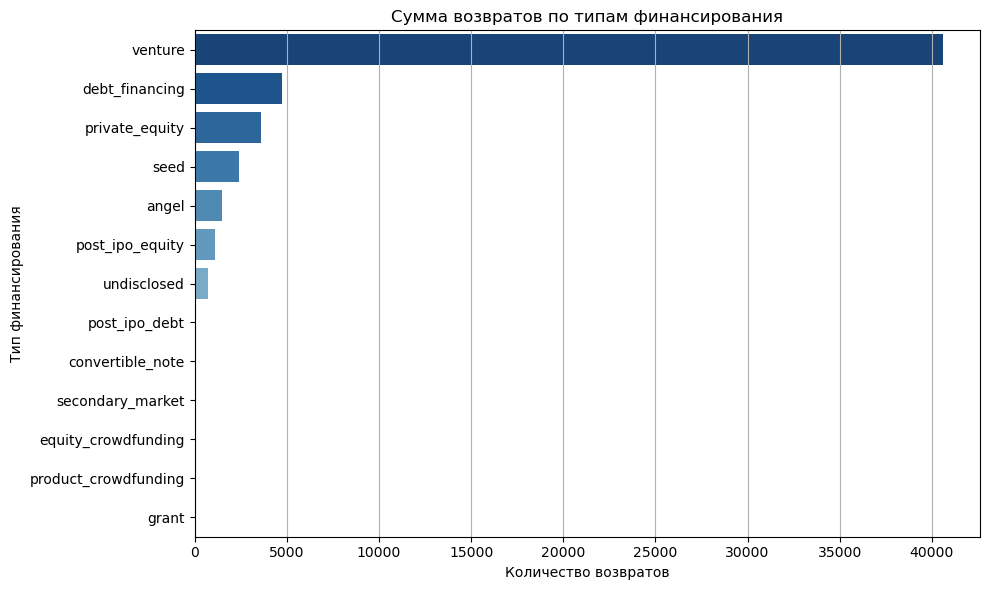

In [89]:
# Строим график по полученным данным
plt.figure(figsize=(10, 6))
plot_data = pd.DataFrame({
    'return_amount': total_returns.values,
    'financing_type': total_returns.index
})

sns.barplot(
    data=plot_data,
    x='return_amount',
    y='financing_type',
    hue='financing_type',
    palette='Blues_r',
    legend=False 
)

plt.title('Сумма возвратов по типам финансирования')
plt.xlabel('Количество возвратов')
plt.ylabel('Тип финансирования')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

На первых местах по объёмам возвратов - `venture`, `debt_financing`, `private_equity`. `venture` в лидерах с огромным отрывом от второго места.

Минимальные возвраты приходятся на `grant`(тут и вовсе нулевое значение), `product_crowdfunding`, `equity_crowdfunding`.

`grant` по своей природе является безвозвратной инвестицией. Это означает, что средства, предоставленные в рамках `grant`, не требуют возврата, если получатель соблюдает условия договора. Именно поэтому мы видим нулевые значения, значит можно предположить, что все условия между компанией и инвесторами были соблюдены.

## 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

In [90]:
# Рассчитаем средний объем раунда
clean_df = clean_df.copy()
clean_df['average_round_size'] = (clean_df['funding_total_usd'] / clean_df['funding_rounds'])
df_grouped = clean_df.groupby('funding_year').agg(
    {'average_round_size': 'median', 'funding_rounds': 'sum'}
).reset_index()
df_grouped

,funding_year,average_round_size,funding_rounds
0,2000.00,2125000.00,112.00
1,2001.00,1570886.00,66.00
2,2002.00,3225000.00,98.00
3,2003.00,1500000.00,125.00
4,2004.00,3000000.00,181.00
5,2005.00,4500000.00,948.00
6,2006.00,3900000.00,1850.00
7,2007.00,2875000.00,2839.00
8,2008.00,2175000.00,3665.00
9,2009.00,1500000.00,4627.00


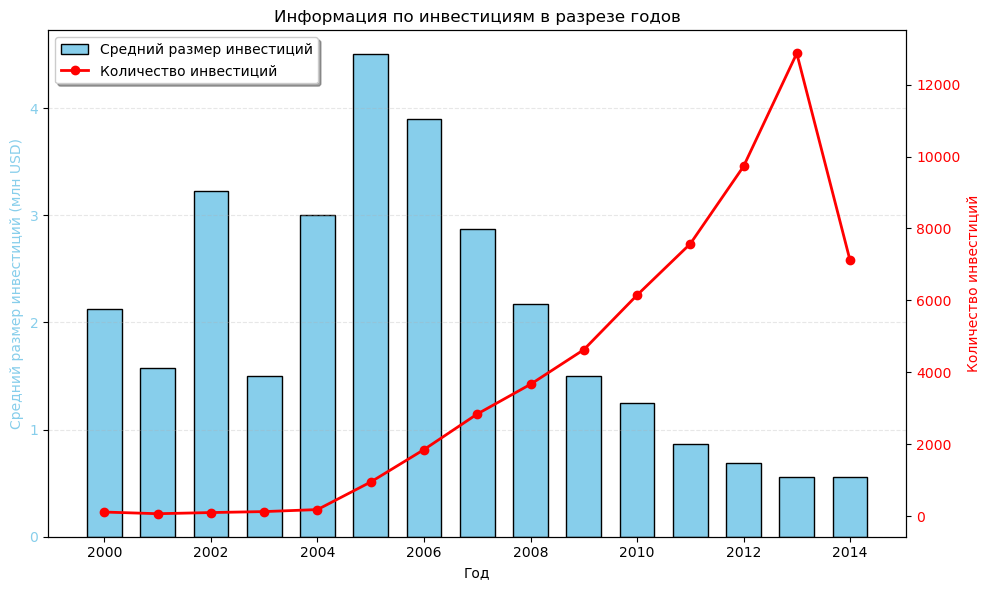

In [91]:
# Строим совместный график
fig, ax1 = plt.subplots(figsize=(10, 6))

# Столбчатая диаграмма: средний размер инвестиций
ax1.bar(
    df_grouped['funding_year'],
    df_grouped['average_round_size'] / 1e6,  # Переводим в млн USD
    width=0.65,
    color='skyblue',
    edgecolor='black',
    label='Средний размер инвестиций'
)

# Вторая ось Y для количества раундов
ax2 = ax1.twinx()

# Линейный график: количество инвестиций
ax2.plot(
    df_grouped['funding_year'],
    df_grouped['funding_rounds'],
    color='red',
    marker='o',
    linewidth=2,
    markersize=6,
    label='Количество инвестиций'
)

# Настройка первой оси (левая)
ax1.set_ylabel('Средний размер инвестиций (млн USD)', color='skyblue')
ax1.set_xlabel('Год')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')

# Настройка второй оси (правая)
ax2.set_ylabel('Количество инвестиций', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Общий заголовок
plt.title('Информация по инвестициям в разрезе годов')


# Единая легенда (объединяем обе оси)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, fancybox=True, shadow=True)


# Улучшаем читаемость меток X
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha='center')


# Убираем лишние пробелы
plt.tight_layout()
plt.show()

По данному графику можно отметить, что самый большой объём инвестиций пришёлся на 2005 год, далее пошёл динамический спад.

А вот по количеству инвестиций лидером стал 2013 год, но общая сумма мала.

У 2014 года по количеству инвестиций значительно ниже по сравнению с 2013 (7113 против 12870), по суммам в равных пределах.

На основе этого графика можно отметить, что снижение среднего размера раунда при росте числа сделок может нам говорить о следующем:

* рынок стал доступнее для стартапов;
* инвесторы используют более гибкие стратегии.

Средний размер раунда - дробление инвестиций, рост доли начальных этапов.

Количество раундов - повышение активности рынка: больше стартапов, больше сделок.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберём из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам. Рассматрим только массовые сегменты.

In [92]:
# Сделаем сводную таблицу с учетом роста в 2014 году
pivot_table = pd.pivot_table(
    clean_df,
    values='funding_total_usd',
    index='funding_year',
    columns='market',
    aggfunc='sum',
    fill_value=0
)

growth_segments = pivot_table.loc[2014] > pivot_table.loc[2013]
filtered_segments = pivot_table.columns[growth_segments]
filtered_pivot = pivot_table[filtered_segments]

In [93]:
# Отфильтруем массовый сегмент
massive_segments = filtered_pivot.columns[~filtered_pivot.columns.str.contains('mid|niche')]
final_pivot = filtered_pivot[massive_segments]
final_pivot

market,apps,big data,design,internet,manufacturing,medical,real estate,saas,startups,technology
funding_year,,,,,,,,,,
2000.00,0.00,0.00,0.00,10000000.00,56659310.00,24000000.00,2500000.00,0.00,0.00,0.00
2001.00,0.00,0.00,0.00,0.00,2368582.00,0.00,0.00,0.00,0.00,22160000.00
2002.00,0.00,0.00,0.00,1100000.00,0.00,0.00,5275000.00,2000000.00,0.00,11000000.00
2003.00,0.00,0.00,0.00,0.00,4269608.00,0.00,6292200.00,0.00,0.00,0.00
2004.00,0.00,0.00,0.00,10500000.00,3000000.00,0.00,0.00,0.00,0.00,1750000.00
2005.00,0.00,0.00,9300000.00,1775000.00,61770000.00,11090000.00,250000.00,5240000.00,0.00,50728425.00
2006.00,1310600.00,0.00,707000.00,5000.00,163957751.00,20250000.00,2080000.00,4791121.00,0.00,22791000.00
2007.00,0.00,7780000.00,10800000.00,4495379.00,147726051.00,2100000.00,33220000.00,14652595.00,0.00,180190209.00
2008.00,4300000.00,2452515.00,5944302.00,23412964.00,173054260.00,28812744.00,46613100.00,27226900.00,5010387.00,277726238.00


In [94]:
# Выведем список оставшихся сегментов
final_pivot.columns.tolist()

['apps',
 'big data',
 'design',
 'internet',
 'manufacturing',
 'medical',
 'real estate',
 'saas',
 'startups',
 'technology']

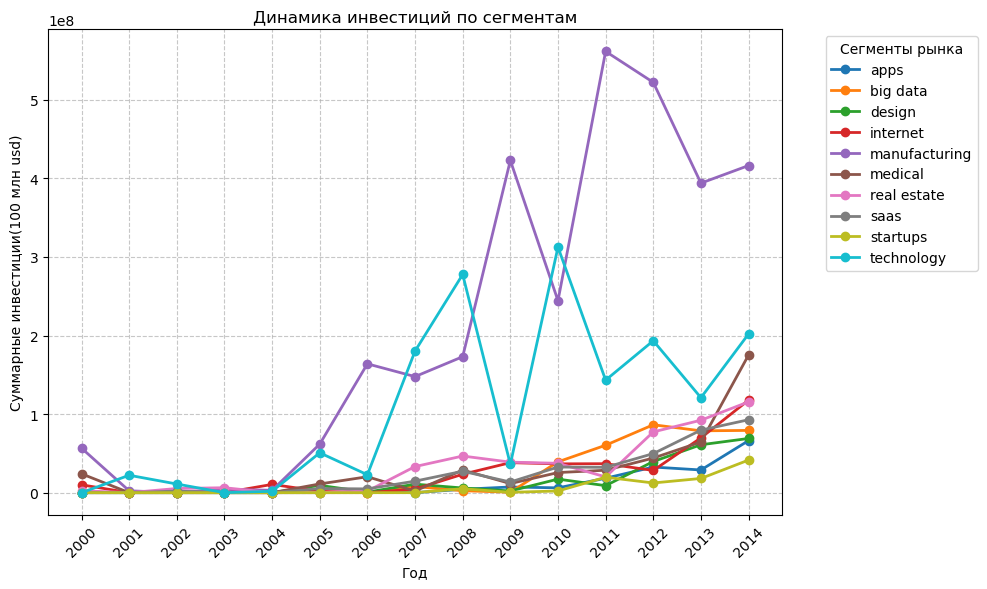

In [95]:
# Нарисуем график
fig, ax = plt.subplots(figsize=(10, 6))

# Рисуем линии для каждого сегмента
for column in final_pivot.columns:
    ax.plot(
        final_pivot.index,
        final_pivot[column],
        marker='o',
        linewidth=2,
        markersize=6,
        label=column
    )

# Настройки осей
ax.set_xlabel('Год')
ax.set_ylabel('Суммарные инвестиции(100 млн usd)')
ax.set_title('Динамика инвестиций по сегментам')


# Легенда
ax.legend(title='Сегменты рынка', bbox_to_anchor=(1.05, 1), loc='upper left')


# Сетка
ax.grid(True, linestyle='--', alpha=0.7)


# Улучшаем читаемость меток оси X
plt.xticks(final_pivot.index, rotation=45)


# Отступы
plt.tight_layout()

plt.show()

Изучим более детально график, выведем ТОП-5 по темпу роста.

Топ‑5 сегментов по темпам роста:
['manufacturing', 'technology', 'medical', 'real estate', 'internet']


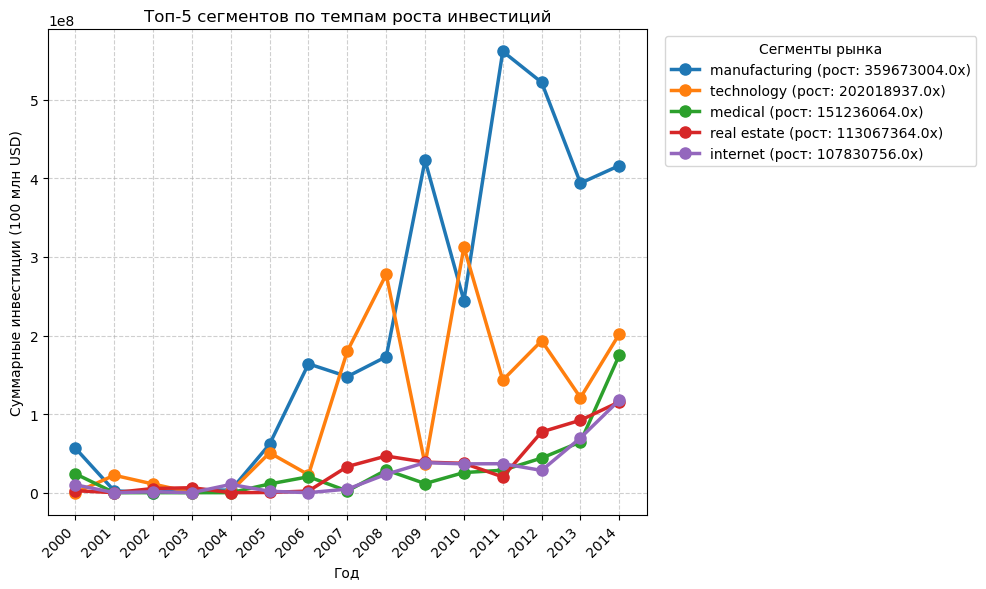

In [96]:
# Вычисляем рост для каждого сегмента(абсолютный прирост)
growth_ratios = final_pivot.iloc[-1] - final_pivot.iloc[0]


# Сортируем по убыванию роста и берём топ‑5
top_5_segments = growth_ratios.sort_values(ascending=False).head(5).index


print("Топ‑5 сегментов по темпам роста:")
print(top_5_segments.tolist())


# Фильтруем данные — оставляем только топ‑5 сегментов
top_5_data = final_pivot[top_5_segments]


# Строим график для топ‑5
fig, ax = plt.subplots(figsize=(10, 6))


for column in top_5_data.columns:
    ax.plot(
        top_5_data.index,
        top_5_data[column],
        marker='o',
        linewidth=2.5,
        markersize=8,
        label=f'{column} (рост: {growth_ratios[column]:.1f}x)'
    )

# Настройки осей
ax.set_xlabel('Год')
ax.set_ylabel('Суммарные инвестиции (100 млн USD)')
ax.set_title('Топ‑5 сегментов по темпам роста инвестиций')


# Легенда
ax.legend(title='Сегменты рынка', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)


# Сетка
ax.grid(True, linestyle='--', alpha=0.6)


# Метки оси X: годы, повёрнуты для читаемости
plt.xticks(top_5_data.index, rotation=45, ha='right')


# Отступы
plt.tight_layout()

plt.show()

Сегменты `internet` и `real estate` показывают стабильный плавный рост.

`medical` в 2014 году выдал динамичный скачок, по сравнению с ранними годами.

`manufacturing` не смотря на скачки, держится на довольно высоком уровне инвестиций. В 2014 году наблюдается рост по сравнению с 2013 годом.

`big data` последние годы держится примерно на одном уровне, на старте выдал хороший скачок.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Для каждого года и каждого вида финансирования рассчитаем нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, заменим на пропуски.

In [97]:
# Группируем инвестиции по годам
investments_grouped = (
    clean_df.groupby('funding_year')
    [['seed', 'venture', 'equity_crowdfunding',
      'undisclosed', 'convertible_note', 'debt_financing',
      'angel', 'grant', 'private_equity', 'post_ipo_equity',
      'post_ipo_debt', 'secondary_market', 'product_crowdfunding']]
    .sum()
)

df_returns = df_returns * 1000000 # масштаб возвратов ровняем с масштабом инвестиций

# Сливаем таблицы
merged_df = pd.merge(
    investments_grouped,
    df_returns,
    left_index=True,
    right_index=True,
    how='outer',
    suffixes=('_invested', '_returned')
)

# Функция расчёта долей
def calculate_normalized_returns(df):
    funding_types = [
        'seed', 'venture', 'equity_crowdfunding',
        'undisclosed', 'convertible_note', 'debt_financing',
        'angel', 'grant', 'private_equity', 'post_ipo_equity',
        'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
    ]
    
    for fund_type in funding_types:
        invested_col = f'{fund_type}_invested'
        returned_col = f'{fund_type}_returned'
        ratio_col = f'{fund_type}_return_ratio'
        
        # Проверяем существование колонок
        if invested_col in df.columns and returned_col in df.columns:
            df[ratio_col] = (
                df[returned_col] / (df[invested_col])
            )
        else:
            print(f"Пропущена колонка: {fund_type} (нет {invested_col} или {returned_col})")
    
    return df

# Применяем функцию
normalized_df = calculate_normalized_returns(merged_df)

# Функция для замены бесконечностей на Nan
def remove_outliers_iqr(df, ratio_cols, replace_inf=True):
    df_clean = df.copy()
    
    if replace_inf:
        df_clean[ratio_cols] = df_clean[ratio_cols].replace(np.inf, np.nan)
    
    for col in ratio_cols:
        if col in df_clean.columns:
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
           
            df_clean.loc[
                (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound),
                col
            ] = np.nan
    
    return df_clean
ratio_cols = [col for col in normalized_df.columns if '_return_ratio' in col]

normalized_df = remove_outliers_iqr(normalized_df, ratio_cols, replace_inf=True)
normalized_df

,seed_invested,venture_invested,equity_crowdfunding_invested,undisclosed_invested,convertible_note_invested,debt_financing_invested,angel_invested,grant_invested,private_equity_invested,post_ipo_equity_invested,...,undisclosed_return_ratio,convertible_note_return_ratio,debt_financing_return_ratio,angel_return_ratio,grant_return_ratio,private_equity_return_ratio,post_ipo_equity_return_ratio,post_ipo_debt_return_ratio,secondary_market_return_ratio,product_crowdfunding_return_ratio
funding_year,,,,,,,,,,,,,,,,,,,,,
2000.00,16759140.00,327962152.00,0.00,104602640.00,0.00,14000000.00,24086333.00,293114.00,0.00,3467747.00,...,0.75,NaN,0.62,0.27,0.00,NaN,0.27,NaN,0.03,NaN
2001.00,4098965.00,208318371.00,0.00,37724067.00,1500000.00,5829217.00,1000000.00,100000.00,0.00,0.00,...,0.57,NaN,0.77,1.18,0.00,NaN,NaN,NaN,NaN,NaN
2002.00,10465192.00,306940622.00,0.00,42323731.00,0.00,15309671.00,3000000.00,0.00,7500000.00,300000.00,...,0.61,NaN,0.22,1.14,NaN,NaN,1.13,NaN,NaN,NaN
2003.00,15318355.00,372234425.00,0.00,10280000.00,0.00,1050000.00,5629661.00,16850717.00,0.00,0.00,...,0.91,NaN,1.04,0.61,0.00,NaN,NaN,NaN,NaN,NaN
2004.00,18104728.00,664150451.00,0.00,62912359.00,0.00,30816623.00,11013741.00,10363600.00,0.00,0.00,...,0.53,NaN,0.44,0.83,0.00,NaN,NaN,NaN,NaN,NaN
2005.00,39425198.00,4809710779.00,0.00,8871332.00,0.00,101720656.00,60914621.00,6266481.00,5000000.00,4796022.00,...,1.07,NaN,0.34,0.51,0.00,0.48,0.73,NaN,NaN,NaN
2006.00,64894774.00,9027404123.00,933057.00,61545498.00,10702385.00,140848395.00,70756153.00,6147500.00,17820244.00,0.00,...,0.76,NaN,0.80,0.67,0.00,0.94,NaN,NaN,NaN,NaN
2007.00,192296481.00,12034596644.00,0.00,109649902.00,14116788.00,211601638.00,201152441.00,34237779.00,153370229.00,12000000.00,...,0.50,NaN,0.59,0.82,0.00,0.58,2.03,NaN,NaN,NaN
2008.00,295133020.00,14249960171.00,0.00,119920337.00,28600902.00,425122061.00,249299613.00,23485347.00,191756331.00,36000000.00,...,0.34,0.06,0.94,0.41,0.00,0.68,2.34,NaN,NaN,0.00


In [98]:
# Выбираем нужные типы финансирования
target_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
ratio_cols = normalized_df.filter(like='_return_ratio').sort_index()


# Формируем список нужных колонок (с _return_ratio)
target_cols = [f"{t}_return_ratio" for t in target_types]
# Оставляем только существующие колонки
target_cols = [col for col in target_cols if col in ratio_cols.columns]

if not target_cols:
    raise ValueError("Нет данных для указанных типов финансирования!")

ratio_cols_actual = ratio_cols[target_cols]
ratio_cols_actual = ratio_cols_actual.sort_index(axis=1)
ratio_cols_actual

,angel_return_ratio,debt_financing_return_ratio,private_equity_return_ratio,seed_return_ratio,venture_return_ratio
funding_year,,,,,
2000.00,0.27,0.62,NaN,1.00,0.17
2001.00,1.18,0.77,NaN,0.70,0.11
2002.00,1.14,0.22,NaN,0.63,0.68
2003.00,0.61,1.04,NaN,0.51,0.63
2004.00,0.83,0.44,NaN,0.55,0.84
2005.00,0.51,0.34,0.48,0.67,0.55
2006.00,0.67,0.80,0.94,0.95,0.34
2007.00,0.82,0.59,0.58,0.37,0.30
2008.00,0.41,0.94,0.68,0.30,0.19


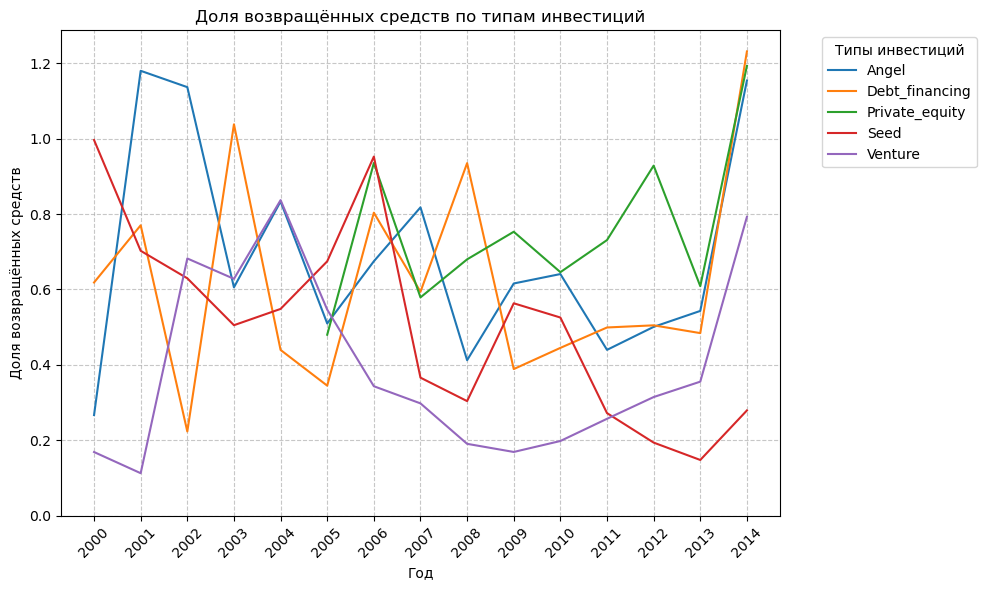

In [99]:
# Создаём график
fig, ax = plt.subplots(figsize=(10, 6))


# Рисуем линии для каждого типа финансирования
for col in ratio_cols_actual.columns:
    ax.plot(
        ratio_cols_actual.index,
        ratio_cols_actual[col],
        label=col.replace('_return_ratio', '').capitalize()
    )

# Оформляем график
ax.set_title('Доля возвращённых средств по типам инвестиций')
ax.set_xlabel('Год')
ax.set_ylabel('Доля возвращённых средств')


# Добавляем сетку
ax.grid(True, linestyle='--', alpha=0.7)


# Легенда
ax.legend(title='Типы инвестиций', bbox_to_anchor=(1.05, 1), loc='upper left')


# Ограничиваем диапазон оси Y
ax.set_ylim(bottom=0)


# Улучшаем отображение годов на оси X
plt.xticks(ratio_cols_actual.index, rotation=45)


plt.tight_layout()
plt.show()

Снижение или рост объёма инвестиций по определённой категории не всегда напрямую указывает на изменение эффективности этого типа инвестиций.

На динамику влияют множество факторов: экономическая ситуация, доступность финансов(капитала), изменения на как внутри рынка, так и на всех рынках, предпочтения, скорость и стадии развитий и так далее.

## 5. Итоговый вывод и рекомендации

В ходе исследования была проведена подготовка датасета к работе, исследование динамики и структуры инвестиций стартапов.

В рамках проекта:
* проведена предобработка данных,удаление дубликатов и пропусков, проверка корректности числовых и временных значений;
* выделены группы компаний по срокам инвестиций и сравнение их по количеству и объёму инвестиций;
* классификация по сегментам рынка на массовые, средние и нишевые;
* определение типичных и аномальных значений объёмов инвестиций, исключение выбросов и ограничение периода исследования;
* сравнение популярности и объёмов разных типов инвестиций;
* анализ динамики раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка;
* расчёт долей возврата средств для разных типов инвестирования и оценка её устойчивость.


Выводы:

* Венчурные инвестиции (`Venture`) показывают отличную динамику и являются популярными типом инвестирования(за весь период вложено 128536698880 usd);

* огромное количество компаний получают единичные инвестиции, но большая часть инвестиций направалена именно на компании со сроком более года;

* ТОП‑5 сегментов по темпам роста (2007–2014):`manufacturing`, `medical`, `internet`, `real estate`, `saas`;

* есть изменчивость в динамике возврата средств по годам, что требует дополнительных исследований для выявления влияющих факторов.

В целом анализ подтвердил устойчивость массовых сегментов.
Лучше ставку делать на копмании со сроком финансирования более 1 года.
И инвестиции со стабильным ростом возврата - `Venture`.